In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
import tifffile
from skimage.measure import regionprops_table
import random
from matplotlib.colors import BoundaryNorm

import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score, silhouette_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import adjusted_mutual_info_score
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
# Consistent colours for the three cell types.
CT_ORDER = ["endothelial", "fibroblast", "unknown"]
CT_COLORS = {"endothelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}
true_gene_columns = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']
all_data = pd.read_csv("clean_data_with_assigned_cell_type.csv")
X = all_data[list(true_gene_columns)].astype(int).to_numpy()


# Spatial & genetic subpopulation analysis

From here the lineage is the **scoring** definition (`cell_type` + `confident`). The
working frame **`df`** keeps **every cell and every state** (no rare-state filtering);
the all-0-read cells have been split into lineages at the confident ratio so they can
join the full-population statistics.

**Coordinates** are converted to microns using the acquisition pixel sizes
(xy = 0.1893014 um, z = 0.7996567 um), and every spatial calculation is performed
*within each image* (`source_folder`) so neighbourhoods never span different images.

**Roadmap**
1. **Pairwise gene interactions** - which genes switch on together across the population,
   then within endothelial and fibroblast separately.
2. **Gene states -> cell states** - do cells fall into discrete states or a continuum? A
   Bernoulli mixture (with soft responsibilities) and a logistic PCA, cross-checked against
   whether the states form real spatial patches.
3. **Neighbourhood niches** - recurring tissue micro-environments from each cell's local
   gene expression, and what defines them.
4. **Gene modules** - a gene-gene interaction graph (positive co-occurrence) and how the
   modules map onto the niches.


## 0. Setup - analysis frame & physical coordinates


In [17]:
# Working frame: EVERY cell, scoring lineage definition (cell_type / confident / tier).
df = combined.copy().reset_index(drop=True)

In [18]:
# Convert to physical coordinates witin the image (each image has its own coordinate origin)
GENES = list(true_gene_columns)      # the 18 real genes (FP channels excluded)
IMAGE_KEY = "source_folder"          # one physical image per source_folder

# Working frame + physical coordinates.
df["x_um"] = df["nucleus_centroid_x"] * XY_UM
df["y_um"] = df["nucleus_centroid_y"] * XY_UM
df["z_um"] = df["nucleus_centroid_z"] * Z_UM

# Binary gene matrix (cells x genes) reused throughout.
X = df[GENES].astype(int).to_numpy()

# Consistent colours for the three cell types.
CT_ORDER = ["endothelial", "fibroblast", "unknown"]
CT_COLORS = {"endothelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}

print("\nCell-type counts:")
print(df["cell_type"].value_counts())


Cell-type counts:
cell_type
endothelial    10729
unknown         1352
fibroblast       966
Name: count, dtype: int64


## 1. Pairwise gene interactions

Which genes switch on together, and which are mutually exclusive? For every pair we
build a 2x2 on/off table, compute the odds ratio, and test it with **Fisher's exact
test** (Benjamini-Hochberg FDR).

- **Global (full population).** All 18 genes across **every** cell, including the all-0
  cells (split into lineages by the confident ratio) and the unknown-lineage cells.
  This asks which genes co-occur in the population as a whole. Note that the many
  both-off cells inflate positive odds ratios (the empty bottom-right corner of the
  2x2), so the global map is best read for *relative* structure, not absolute effect
  sizes.
- **Within lineage (confident cells only).** Splitting on `cell_type` and then testing
  two *marker* genes is circular - the markers helped define the lineage. Instead of
  leave-two-out, we restrict each lineage to its **confident** cells (>=2 of that
  lineage's markers and **none** of the other lineage's). Cross-lineage pairs (e.g.
  `COL1A1` inside endothelial) are then all-zero -> not testable, so the cross-lineage
  artefact cannot arise.
  - **Caveat (collider bias).** Selecting on ">=2 of a lineage's markers" makes *those
    markers* artificially anti-correlate within the subset (Berkson's paradox). So a
    pair where **both** genes are that lineage's defining markers is not interpretable -
    most visible for fibroblast, where "2 of 3" forces `COL1A1`/`COL1A2`/`PDGFRB` to
    look mutually exclusive. We therefore **flag and exclude defining-marker pairs** and
    read only the non-marker pairs (e.g. `APLN`-`ANGPT2`, `MMP1`-`DLL4` in endothelial),
    which carry no such bias.



In [45]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=5, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

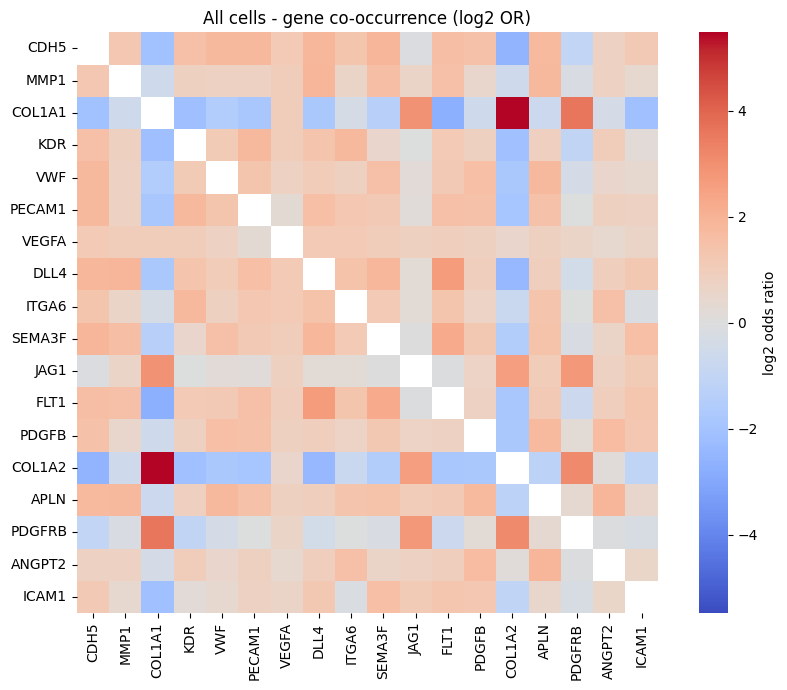

Significant pairs (FDR<0.05): 123  (co-occurring: 101, exclusive: 22)

Most significant co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,608,509,278,23.719782,44.439079,5.473757,2.855165e-252
2,CDH5,KDR,4889,3548,1981,1329.514218,2.864849,1.518459,2.547955e-149
3,CDH5,VWF,4889,2269,1403,850.244577,3.387900,1.760391,1.122826e-146
4,CDH5,PECAM1,4889,1960,1225,734.455430,3.375395,1.755056,5.946295e-130
49,KDR,PECAM1,3548,1960,994,533.002223,3.437354,1.781298,1.206684e-127
6,CDH5,DLL4,4889,1393,913,521.987967,3.671052,1.876194,2.521302e-110
101,DLL4,FLT1,1393,721,278,76.979612,6.311400,2.657960,1.171710e-91
5,CDH5,VEGFA,4889,3845,1950,1440.806699,2.192632,1.132664,6.604292e-88
8,CDH5,SEMA3F,4889,922,619,345.493830,3.754721,1.908706,1.601486e-78
22,MMP1,DLL4,1178,1393,317,125.772515,3.695189,1.885648,1.482674e-60


Most significant mutually-exclusive gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
12,CDH5,COL1A2,4889,509,48,190.733579,0.167086,-2.581338,1.342468e-47
1,CDH5,COL1A1,4889,608,78,227.831072,0.234608,-2.091676,1.026105e-42
33,COL1A1,KDR,608,3548,48,165.339465,0.220978,-2.178025,1.859079e-33
57,KDR,COL1A2,3548,509,41,138.417414,0.228087,-2.132343,1.460748e-27
35,COL1A1,PECAM1,608,1960,30,91.337472,0.287018,-1.800788,4.920342e-15
70,VWF,COL1A2,2269,509,30,88.520043,0.292534,-1.773324,2.565429e-14
34,COL1A1,VWF,608,2269,42,105.737104,0.343956,-1.539702,5.261975e-14
82,PECAM1,COL1A2,1960,509,23,76.465088,0.264308,-1.919707,5.414428e-14
103,DLL4,COL1A2,1393,509,11,54.344830,0.186164,-2.425355,3.267477e-13
37,COL1A1,DLL4,608,1393,21,64.914846,0.295099,-1.760729,8.418605e-11


In [49]:
#  Full population (all cells, incl. all-0 and unknown lineage)
res_all, M_all = pairwise_cooccurrence(
    df, GENES, title="All cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

# Readable labels for the summary tables.
show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
sig.to_csv("all_cells_sig_pairs.csv")
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nMost significant co-occurring gene pairs:")
display(sig[sig.log2_OR > 0].sort_values("FDR").head(20)[cols].rename(columns=show_cols))
print("Most significant mutually-exclusive gene pairs:")
display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))

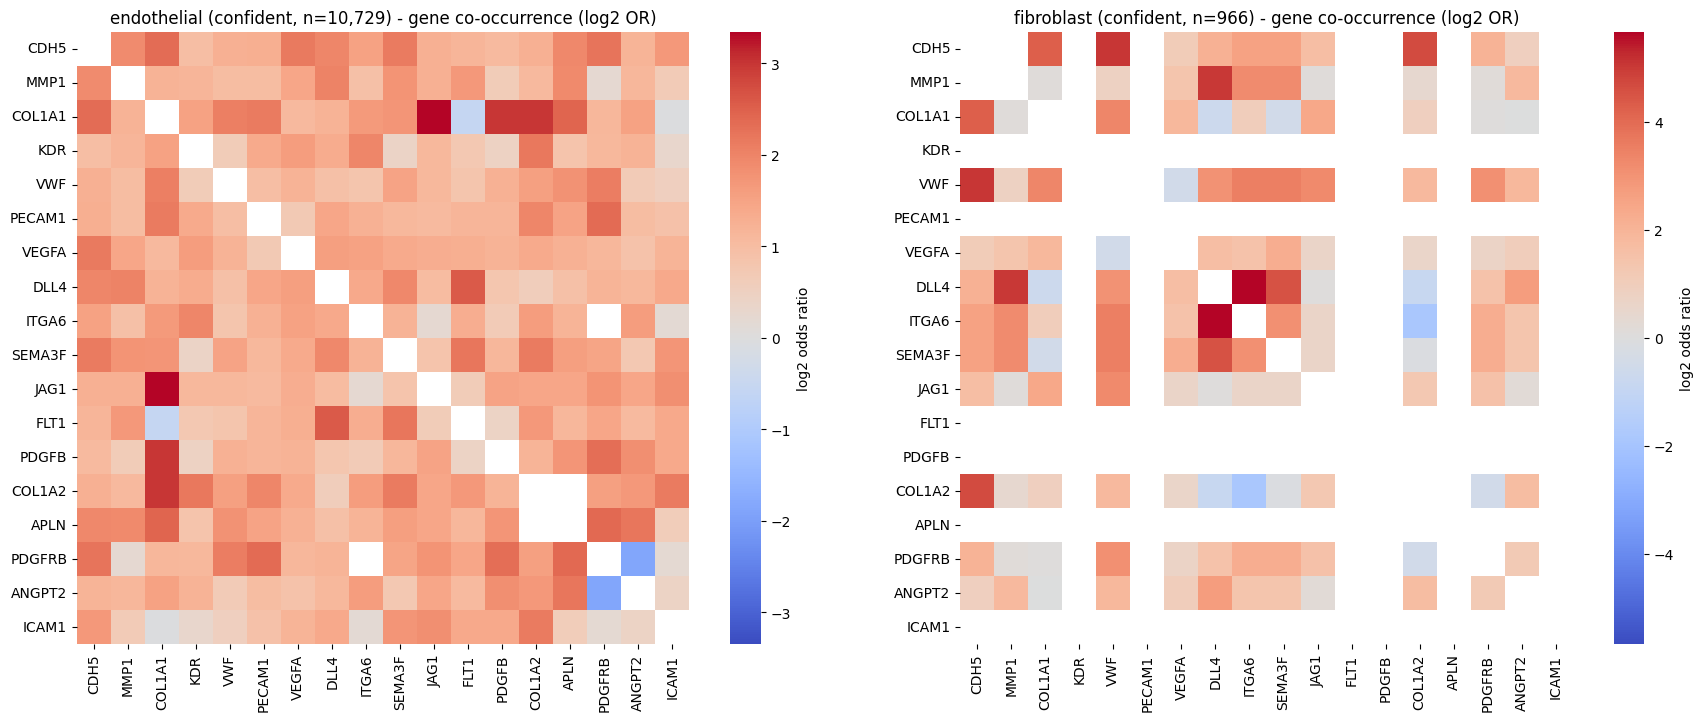

In [69]:
# Within-lineage co-occurrence WITHOUT circularity - use CONFIDENT cells only.
# A confident cell expresses >=2 of its lineage's markers and NONE of the other's, so
# the opposite lineage's markers are all-zero here and their pairs are simply not
# testable. No leave-two-out needed: any testable pair is a genuine co-occurrence.
lineages = ["endothelial", "fibroblast"]
fig, axes = plt.subplots(1, len(lineages), figsize=(9 * len(lineages), 7))
lineage_res = {}
for ax, lineage in zip(axes, lineages):
    sub = df[(df["cell_type"] == lineage)] # & (df["confident"])]
    res, M = pairwise_cooccurrence(
        sub, GENES, ax=ax, 
        title=f"{lineage} (confident, n={len(sub):,}) - gene co-occurrence (log2 OR)")
    lineage_res[lineage] = res
plt.tight_layout(); plt.show()

In [50]:
# Significant within-lineage pairs (confident cells only).
# CAVEAT: a "confident" cell is selected on >=2 of its own markers, which makes those
# defining markers artificially anti-correlate within the subset (collider / Berkson
# bias). So pairs where BOTH genes are that lineage's markers are NOT interpretable -
# we flag them and report the trustworthy (non-marker) pairs separately.
lineage_markers = {"endothelial": set(endo_genes), "fibroblast": set(fibro_genes)}

for lineage in ["endothelial", "fibroblast"]:
    res = lineage_res[lineage].copy()
    mk = lineage_markers[lineage]
    res["both_defining"] = res.gene1.isin(mk) & res.gene2.isin(mk)
    testable = res[res.testable]
    trust = testable[~testable.both_defining]          # interpretable pairs
    biased = testable[testable.both_defining]          # collider-biased, do not interpret
    sig = trust[trust.FDR < 0.05]
    print(f"{lineage}: {len(testable)} testable pairs "
          f"({len(trust)} interpretable, {len(biased)} defining-marker pairs excluded); "
          f"{len(sig)} interpretable & significant (FDR<0.05)  "
          f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("  most significant co-occurring (non-marker pairs):")
    display(sig[sig.log2_OR > 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    print("  most significant mutually-exclusive (non-marker pairs):")
    display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    if len(biased):
        print("  defining-marker pairs (collider-biased, NOT interpreted):")
        display(biased[cols].rename(columns=show_cols))

endothelial: 105 testable pairs (90 interpretable, 15 defining-marker pairs excluded); 28 interpretable & significant (FDR<0.05)  (co-occurring: 25, exclusive: 3)
  most significant co-occurring (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
101,DLL4,FLT1,885,612,243,130.103291,2.984213,1.577350,7.203636e-28
118,SEMA3F,FLT1,550,612,154,80.855153,2.681724,1.423161,7.048073e-17
22,MMP1,DLL4,599,885,206,127.339659,2.228471,1.156054,1.264766e-14
99,DLL4,SEMA3F,885,550,175,116.922892,1.909963,0.933545,6.726080e-09
141,PDGFB,ANGPT2,690,262,81,43.425414,2.425677,1.278388,2.839330e-08
26,MMP1,FLT1,599,612,132,88.058612,1.819389,0.863454,1.809007e-06
5,CDH5,VEGFA,3306,1704,1418,1353.212587,1.498318,0.583344,3.503819e-06
24,MMP1,SEMA3F,599,550,118,79.137641,1.782490,0.833894,1.059802e-05
148,APLN,ANGPT2,160,262,26,10.069661,3.138670,1.650154,4.018940e-05
124,SEMA3F,ICAM1,550,182,45,24.045160,2.275777,1.186359,1.154112e-04


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
75,PECAM1,VEGFA,1655,1704,564,677.424934,0.620568,-0.688338,4.236346e-12
53,KDR,SEMA3F,2565,550,266,338.878213,0.535479,-0.901099,1.877358e-10
61,KDR,ICAM1,2565,182,92,112.137881,0.623342,-0.681904,9.983903e-03


  defining-marker pairs (collider-biased, NOT interpreted):


...

,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  defining-marker pairs (collider-biased, NOT interpreted):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,280,260,249,250.171821,0.344375,-1.537946,1.000000e+00
45,COL1A1,PDGFRB,280,78,67,75.051546,0.013746,-6.184839,2.269806e-05
144,COL1A2,PDGFRB,260,78,47,69.690722,0.003531,-8.145517,1.461939e-18


### Conclusions - pairwise gene interactions

**Approach.** For every gene pair we build a 2x2 on/off table, take the odds ratio, and
test it with Fisher's exact test (Benjamini-Hochberg FDR). Positive log2 OR = co-occur
more than chance; negative = mutually exclusive.

**Assumptions / drawbacks.** Cells are treated as independent and a `0` means "off" (not a
missed read). Co-occurrence is *association, not regulation*. In the all-cells map the many
double-negative cells inflate positive odds ratios, so read it only for relative structure;
within a lineage, pairs of that lineage's own markers are collider-biased and excluded.

**Biology.** The trustworthy signal is a set of **positively co-occurring** pairs (e.g.
`KDR`-`VEGFA`, `DLL4`-`MMP1`-`FLT1`) - genes belonging to the same programme. The
mutually-exclusive calls are weak and mostly unreliable here, so we do not interpret them.

**Do the methods agree?** Yes - these same positive pairs re-emerge as the **gene modules**
in Section 4 (same statistic, summarised as a graph), so the pairwise test and the module
graph tell a consistent story.

## 2. Which gene states define distinct cell states?

Three complementary views of the same 18-gene 0/1 matrix, asking whether the population
is a few clean types or a **continuum**:

- **Bernoulli mixture** - what recurring probabilistic states exist? BIC picks the number
  of states K.
- **Responsibilities** - how discrete are individual cell assignments? For each cell the
  posterior over states tells us whether it belongs cleanly to one state (discrete) or is
  smeared across several (continuum).
- **Logistic PCA / latent factors** - can those ~K states be explained by a *smaller*
  number of continuous biological axes? If 1-2 latent axes reconstruct most of the
  binary structure, the "states" are really positions along a continuum.

The emphasis is on **endothelial** cells, which we suspect form 2+ overlapping programmes
rather than discrete types.

### What we're trying to find out

Each cell is described by which of the 18 genes it has switched on or off. The big
question: do cells fall into a handful of **clean, distinct types**, or do they blur into
one another along a **continuous gradient**? We look at endothelial and fibroblast cells
separately (the lineages behave very differently), and for the per-lineage runs we
**exclude that lineage's defining markers** (`CDH5`/`VWF`/`PECAM1` for endothelial,
`COL1A1`/`COL1A2` for fibroblast) so the clusters reflect *functional* variation rather
than just re-discovering the markers. Three methods, so the answer doesn't hinge on one.

**1. Grouping cells into recurring patterns (Bernoulli mixture).** Discover a few typical
on/off "signatures" and sort each cell towards the one it resembles; BIC picks how many
signatures are worth having.
- *Assumes* genes switch on independently within a state and a `0` means truly "off".
- *Drawback:* forces hard-ish groups onto data that may be continuous.

**2. How confidently was each cell sorted? (responsibilities).** The mixture also reports
how sure it was per cell ("95% group A" vs "50/50 A/B"). Lots of borderline cells = the
groups are convenient labels on a smooth gradient (a **continuum**).
- *Best single check* for the discrete-vs-continuum question.

**3. Can a few "dials" explain everything? (logistic PCA).** Fits continuous latent axes to
the 0/1 data. If 1-2 axes rebuild most of the pattern, the states are just positions on a
gradient; if it needs many axes, structure is genuinely multi-faceted.
- *Drawback:* axes are statistical, not guaranteed to be single biological programmes.

### What we found (this run)

| Population | cells | # states (K) | % cells sorted confidently (>=0.8) | logistic-PCA (2 axes / 6 axes) | verdict |
|---|---|---|---|---|---|
| all cells | 9,472 | 7 | ~55% | 38% / 85% | continuum-leaning |
| endothelial (markers excluded) | 7,388 | **4** | **38%** | 46% / 93% | **continuum** |
| fibroblast (markers excluded) | 732 | **2** | **99%** | 70% / 99% | **discrete** |

### How to read this + do the methods agree?

**Yes - all three methods agree, per lineage.**
- **Fibroblasts are discrete.** Only 2 states, *almost every* cell sorted with high
  confidence (99% >=0.8), and logistic PCA saturates fast (70% of the pattern in 2 axes).
  Different starting points converge on the same answer: a few clean states.
- **Endothelial cells are a continuum.** Even with only 4 states, just ~38% of cells are
  confidently assigned - most sit *between* states - and logistic PCA keeps climbing with
  no early plateau (needs ~6 axes). All three signals point the same way: endothelial cells
  are **not discrete types** but a smooth spread, built on a shared `CDH5` backbone, whose
  strongest axis is `KDR`/`VEGFA` **angiogenic** activation, with a smaller `DLL4`/`FLT1`
  tip/sprouting flavour.

**Interpretation in words:** treat the endothelial "clusters" as *waypoints along a
gradient of angiogenic activation*, not as separate cell types; treat the fibroblast
clusters as genuine states. The spatial test below then asks whether these gradient
waypoints occupy real tissue territory (they do for the angiogenic states).

In [34]:
# Shared helpers + a readable cluster summariser used by every approach in section 2.

def binary_state_to_code(binary_state):
    """'100100...' -> '1_4' (1-indexed positions of the ON genes; '0' if none on)."""
    genes_on = [str(position + 1) for position, bit in enumerate(binary_state) if bit == "1"]
    return "_".join(genes_on) if genes_on else "0"


def state_code_to_gene_names(state_code, genes):
    """'1_4_7' -> 'CDH5, KDR, VWF' using the 1-indexed gene order ('0' -> 'none')."""
    if state_code == "0":
        return "none"
    return ", ".join(genes[int(position) - 1] for position in state_code.split("_"))


def describe_clusters(cells, cell_labels, genes, method_name, cell_type, top_states=3):
    """Print a plain-English summary of one method's clusters for one cell type.

    For every cluster it lists the gene states that dominate it, e.g.
    "cluster 1 (120 cells, 34%): likely states include 60% 1_4 (CDH5, KDR); ...".
    Cells with label -1 (unassigned) are ignored. Returns the same information as a
    tidy DataFrame so it can be collected and saved.
    """
    labels = pd.Series(cell_labels, index=cells.index)
    assigned = labels[labels >= 0]
    cluster_sizes = assigned.value_counts()
    n_cells = len(assigned)
    print(f"{len(cluster_sizes)} clusters identified for {cell_type} cells "
          f"({method_name}, {n_cells:,} cells):")

    summary_rows = []
    for cluster_id in cluster_sizes.index:
        member_index = assigned[assigned == cluster_id].index
        n = len(member_index)
        state_counts = cells.loc[member_index, "binary_state"].value_counts()
        described = [
            f"{100 * count / n:.0f}% {binary_state_to_code(state)} "
            f"({state_code_to_gene_names(binary_state_to_code(state), genes)})"
            for state, count in state_counts.head(top_states).items()
        ]
        main_states = "; ".join(described)
        print(f"  cluster {cluster_id} ({n:,} cells, {100 * n / n_cells:.0f}%): "
              f"likely states include {main_states}")
        summary_rows.append({
            "cell_type": cell_type,
            "method": method_name,
            "cluster": cluster_id,
            "n_cells": n,
            "pct_of_cell_type": 100 * n / n_cells,
            "main_states": main_states,
        })
    print()
    return pd.DataFrame(summary_rows)

In [35]:
#  Approach 2: Bernoulli mixture (probabilistic) 

def fit_bernoulli_mixture_once(gene_matrix, n_states, max_iter=300, tol=1e-6, rng=None):
    """One EM run of a Bernoulli mixture.

    Returns (weights, on_probabilities, log_likelihood, responsibilities).
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_cells, n_genes = gene_matrix.shape
    on_probabilities = rng.uniform(0.1, 0.9, size=(n_states, n_genes))
    weights = np.full(n_states, 1.0 / n_states)
    log_likelihood_prev = -np.inf
    responsibilities = np.full((n_cells, n_states), 1.0 / n_states)
    for _ in range(max_iter):
        log_prob = (gene_matrix @ np.log(on_probabilities.T)
                    + (1 - gene_matrix) @ np.log(1 - on_probabilities.T)) + np.log(weights)
        row_max = log_prob.max(axis=1, keepdims=True)
        log_norm = row_max.ravel() + np.log(np.exp(log_prob - row_max).sum(axis=1))
        log_likelihood = log_norm.sum()
        responsibilities = np.exp(log_prob - log_norm[:, None])
        cells_per_state = responsibilities.sum(axis=0) + 1e-9
        weights = cells_per_state / n_cells
        on_probabilities = np.clip((responsibilities.T @ gene_matrix) / cells_per_state[:, None],
                                   1e-3, 1 - 1e-3)
        if abs(log_likelihood - log_likelihood_prev) < tol * (abs(log_likelihood_prev) + 1e-9):
            break
        log_likelihood_prev = log_likelihood
    return weights, on_probabilities, log_likelihood, responsibilities

def fit_bernoulli_mixture(gene_matrix, n_states, n_restarts=8, seed=0):
    """Sort cells into `n_states` hidden states using a Bernoulli mixture.

    The idea: imagine a few hidden cell states. Each state has, for every gene, a
    chance that the gene is switched on, and each cell is a slightly noisy copy of one
    state. Fitting the model tells us those states and which one each cell most likely
    belongs to. Because it is a probability model of how the on/off patterns arise, it
    is a good sanity check on the distance-based clustering. It assumes genes turn on
    independently within a state and that a 0 really means "off" (not just missed).

    Runs the fit several times from random starts and keeps the best. Returns a dict
    with the state weights, per-gene on-probabilities, one hard label per cell, the
    full soft responsibilities (cells x states), and the BIC score (lower = better fit
    once the number of states is penalised).
    """
    gene_matrix = np.asarray(gene_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    best_fit = None
    for _ in range(n_restarts):
        candidate = fit_bernoulli_mixture_once(gene_matrix, n_states, rng=rng)
        if best_fit is None or candidate[2] > best_fit[2]:
            best_fit = candidate
    weights, on_probabilities, log_likelihood, responsibilities = best_fit
    labels = responsibilities.argmax(axis=1)
    n_cells, n_genes = gene_matrix.shape
    n_params = n_states * n_genes + (n_states - 1)
    bic = -2 * log_likelihood + n_params * np.log(n_cells)
    return {
        "n_states": n_states,
        "weights": weights,
        "on_probabilities": on_probabilities,
        "labels": labels,
        "responsibilities": responsibilities,
        "bic": bic,
    }


def select_bernoulli_mixture(gene_matrix, candidate_states=range(2, 11), seed=0):
    """Fit the mixture for several numbers of states and keep the lowest-BIC one.

    Returns (best_fit, fits_by_number_of_states).
    """
    fits_by_number_of_states = {
        n_states: fit_bernoulli_mixture(gene_matrix, n_states, seed=seed)
        for n_states in candidate_states
    }
    best_n_states = min(fits_by_number_of_states, key=lambda k: fits_by_number_of_states[k]["bic"])
    return fits_by_number_of_states[best_n_states], fits_by_number_of_states

In [36]:
#  Approach 3: Logistic PCA (continuous latent axes for binary data)
#
# Are the ~K Bernoulli states really a handful of discrete types, or positions along a
# few CONTINUOUS axes? Ordinary PCA assumes Gaussian data; here each gene is 0/1, so we
# use logistic PCA: model P(gene on) = sigmoid(mu_j + scores . loadings_j), i.e. the
# log-odds (natural parameters) are low-rank. Fitted with the majorization-minimization
# (MM) scheme of de Leeuw / Landgraf & Lee - at each step the logistic loss is bounded
# by a quadratic whose minimiser is a plain SVD of a "working response", so it reduces
# to repeated PCA and converges monotonically.

def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))


def binary_deviance(binary_matrix, natural_params):
    """-2 * Bernoulli log-likelihood of `binary_matrix` given log-odds `natural_params`."""
    p = np.clip(_sigmoid(natural_params), 1e-9, 1 - 1e-9)
    return -2.0 * np.sum(binary_matrix * np.log(p) + (1 - binary_matrix) * np.log(1 - p))


def fit_logistic_pca(binary_matrix, n_components, max_iter=200, tol=1e-6):
    """Logistic PCA of a binary (cells x genes) matrix via MM / iterated SVD.

    Models the log-odds as  Theta = mu + scores @ loadings.T  (rank n_components).
    Returns a dict with:
      mu         : per-gene intercept (log-odds of the marginal ON-rate),
      scores     : cells x n_components latent coordinates (the continuous axes),
      loadings   : genes x n_components gene weights on each axis,
      deviance   : -2 log-likelihood of the fitted rank-k model (lower = better).
    """
    X = np.asarray(binary_matrix, dtype=float)
    n_cells, n_genes = X.shape
    p0 = np.clip(X.mean(axis=0), 1e-3, 1 - 1e-3)
    mu = np.log(p0 / (1 - p0))
    theta = np.tile(mu, (n_cells, 1))
    scores = np.zeros((n_cells, n_components))
    loadings = np.zeros((n_genes, n_components))
    deviance_prev = np.inf
    for _ in range(max_iter):
        # MM working response: quadratic surrogate to the logistic loss (Hessian <= 1/4).
        working = theta + 4.0 * (X - _sigmoid(theta))
        mu = working.mean(axis=0)
        centred = working - mu
        U, S, Vt = np.linalg.svd(centred, full_matrices=False)
        k = min(n_components, len(S))
        scores = U[:, :k] * S[:k]
        loadings = Vt[:k].T
        theta = mu + scores @ loadings.T
        deviance = binary_deviance(X, theta)
        if abs(deviance_prev - deviance) < tol * (abs(deviance_prev) + 1e-9):
            break
        deviance_prev = deviance
    return {"mu": mu, "scores": scores, "loadings": loadings, "deviance": deviance}

In [ ]:
# ============================================================================
# SECTION 2 ENGINE - characterise ONE cell subset three ways.
#
#   1. Bernoulli mixture - BIC picks the number of states K; gives per-state on-
#      probabilities (the recurring probabilistic states).
#   2. Responsibilities - the mixture's soft posterior per cell. If cells sit cleanly in
#      one state (max-responsibility ~ 1, low entropy) the structure is DISCRETE; if the
#      posterior is smeared across states, the population is a CONTINUUM.
#   3. Logistic PCA - fits continuous latent axes to the 0/1 matrix. If 1-2 axes explain
#      most of the binary deviance, the K states are really positions on a few axes.
#
# exclude_genes: marker genes that DEFINED the lineage upstream but should NOT drive the
# clustering here (else the clusters just rediscover the markers). They are dropped from
# the matrix fed to all three methods, but kept in binary_state so the state labels still
# show them.
#
# Call it on any subset - the whole population, or a single lineage.
# All-0-read cells are ALWAYS dropped: they carry no gene state to characterise.
# store_to_df writes labels/coords back onto df for section 3 - only pass it for runs
# whose subsets PARTITION df (the per-lineage 'all cells' runs), never for overlapping
# ones.
# ============================================================================



def cluster_and_report(cells, label, max_clusters=8, k_min=2, store_to_df=False,
                       lpca_max_components=6, exclude_genes=None):
    """Bernoulli mixture + responsibility-based discreteness + logistic PCA on one subset.
    Returns a dict (label, cells, K, genes, bmm_labels, responsibilities, max_resp,
    resp_entropy, lpca_by_k, dev_explained, lpca_scores, summaries) or None if <10 cells
    carry reads.
    """
    cells = cells[cells["had_reads"]]
    if len(cells) < 10:
        print(f"{label}: only {len(cells)} cells with reads - skipping\n")
        return None
    exclude_genes = list(exclude_genes or [])
    genes_used = [g for g in GENES if g not in set(exclude_genes)]
    matrix = cells[genes_used].astype(int).to_numpy()
    print("=" * 78)
    print(f"POPULATION: {label}  ({len(cells):,} cells with reads)")
    if exclude_genes:
        print(f"Marker genes excluded from clustering (still define lineage): "
              f"{', '.join(exclude_genes)}")
    print("=" * 78)

    # --- 1. Bernoulli mixture - BIC picks K ---
    best_mixture, mixtures_by_k = select_bernoulli_mixture(
        matrix, candidate_states=range(k_min, max_clusters + 1))
    K = best_mixture["n_states"]
    bmm_labels = best_mixture["labels"]
    responsibilities = best_mixture["responsibilities"]
    print(f"Bernoulli BIC picked K = {K} states.\n")
    summary = describe_clusters(cells, bmm_labels, GENES, "Bernoulli", label)

    # --- 2. Responsibilities - how discrete are the assignments? ---
    max_resp = responsibilities.max(axis=1)
    resp_entropy = -(responsibilities * np.log(responsibilities + 1e-12)).sum(axis=1) / np.log(K)
    pct_confident = 100 * np.mean(max_resp >= 0.8)
    print(f"Assignment discreteness (Bernoulli responsibilities, K={K}):")
    print(f"  mean max-responsibility  : {max_resp.mean():.3f}   (1 = every cell sits in one state)")
    print(f"  cells with max-resp >=0.8: {pct_confident:.1f}%")
    print(f"  mean normalised entropy  : {resp_entropy.mean():.3f}   "
          f"(0 = discrete, 1 = evenly spread across states)\n")

    # --- 3. Logistic PCA - can a few continuous axes explain the states? ---
    p0 = np.clip(matrix.mean(axis=0), 1e-9, 1 - 1e-9)
    theta_null = np.tile(np.log(p0 / (1 - p0)), (len(matrix), 1))
    dev_null = binary_deviance(matrix, theta_null)     # intercept-only baseline
    n_comp_max = int(min(lpca_max_components, matrix.shape[1] - 1))
    lpca_by_k = {k: fit_logistic_pca(matrix, k) for k in range(1, n_comp_max + 1)}
    dev_explained = {k: 1 - lpca_by_k[k]["deviance"] / dev_null for k in lpca_by_k}
    lpca_scores = lpca_by_k[min(2, n_comp_max)]["scores"]   # 2-axis embedding for the map
    print("Logistic PCA - fraction of binary deviance explained by the first n axes:")
    for k in range(1, n_comp_max + 1):
        print(f"  {k} axis{'es' if k > 1 else '  '}: {100 * dev_explained[k]:5.1f}%")
    print()

    # --- Figure 1: model selection + the Bernoulli states themselves ---
    candidate_ks = list(mixtures_by_k)
    bic_values = [mixtures_by_k[k]["bic"] for k in candidate_ks]
    state_probabilities = pd.DataFrame(
        best_mixture["on_probabilities"], columns=genes_used,
        index=[f"state {k} ({weight:.0%})" for k, weight in enumerate(best_mixture["weights"])])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
    axes[0].plot(candidate_ks, bic_values, "o-")
    axes[0].axvline(K, color="red", ls="--", label=f"best K = {K}")
    axes[0].set(xlabel="K (number of states)", ylabel="BIC",
                title=f"{label}: mixture model selection")
    axes[0].legend()
    sns.heatmap(state_probabilities, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
                cbar_kws={"label": "P(gene on | state)"})
    axes[1].set_title(f"{label}: Bernoulli mixture states (K={K})")
    plt.tight_layout(); plt.show()

    # --- Figure 2: continuum diagnostics (responsibilities + logistic PCA) ---
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    axes[0].hist(max_resp, bins=30, range=(1.0 / K, 1.0), color="steelblue")
    axes[0].axvline(0.8, color="red", ls="--", label="0.8")
    axes[0].set(xlabel="max responsibility per cell", ylabel="cells",
                title=f"{label}: assignment confidence\n"
                      f"({pct_confident:.0f}% of cells >=0.8. Low % suggests continuum of states rather than discrete)")
    axes[0].legend()

    ks = list(dev_explained)
    axes[1].plot(ks, [100 * dev_explained[k] for k in ks], "o-")
    axes[1].set(xlabel="number of logistic-PCA axes", ylabel="% binary deviance explained",
                ylim=(0, 100),
                title=f"{label}: logistic PCA\n(sharp early plateau means few continuous axes)")
    axes[1].grid(alpha=0.3)

    # Discrete colour per state so the colourbar ticks line up with the state ids.
    state_cmap = plt.get_cmap("tab10", K)
    state_norm = BoundaryNorm(np.arange(-0.5, K + 0.5, 1.0), K)
    scatter = axes[2].scatter(lpca_scores[:, 0], lpca_scores[:, 1], c=bmm_labels,
                              cmap=state_cmap, norm=state_norm, s=8, alpha=0.6)
    axes[2].set(xlabel="logistic PCA axis 1", ylabel="logistic PCA axis 2",
                title=f"{label}: cells on the latent axes\n(coloured by Bernoulli state)")
    plt.colorbar(scatter, ax=axes[2], label="Bernoulli state", ticks=range(K))
    plt.tight_layout(); plt.show()

    if store_to_df:
        bmm_offset = int(df["bmm"].max()) + 1
        df.loc[cells.index, "bmm"] = bmm_labels + bmm_offset
        df.loc[cells.index, "bmm_confidence"] = max_resp
        df.loc[cells.index, "lpca1"] = lpca_scores[:, 0]
        df.loc[cells.index, "lpca2"] = lpca_scores[:, 1]

    return {
        "label": label, "cells": cells, "K": K, "genes": genes_used,
        "bmm_labels": bmm_labels, "responsibilities": responsibilities,
        "max_resp": max_resp, "resp_entropy": resp_entropy,
        "lpca_by_k": lpca_by_k, "dev_explained": dev_explained, "lpca_scores": lpca_scores,
        "summaries": summary,
    }

POPULATION: all cells (with reads)  (9,472 cells with reads)
Bernoulli BIC picked K = 7 states.

7 clusters identified for all cells (with reads) cells (Bernoulli, 9,472 cells):
  cluster 5 (2,382 cells, 25%): likely states include 19% 4 (KDR); 11% 1_4 (CDH5, KDR); 8% 1_4_7 (CDH5, KDR, VEGFA)
  cluster 4 (2,056 cells, 22%): likely states include 32% 1 (CDH5); 12% 1_7 (CDH5, VEGFA); 9% 1_5 (CDH5, VWF)
  cluster 0 (1,504 cells, 16%): likely states include 3% 1_8 (CDH5, DLL4); 3% 1_7_8 (CDH5, VEGFA, DLL4); 2% 1_4_8 (CDH5, KDR, DLL4)
  cluster 2 (1,273 cells, 13%): likely states include 18% 5 (VWF); 9% 6 (PECAM1); 8% 2 (MMP1)
  cluster 1 (959 cells, 10%): likely states include 63% 7 (VEGFA); 5% 2_7 (MMP1, VEGFA); 5% 5_7 (VWF, VEGFA)
  cluster 3 (684 cells, 7%): likely states include 15% 3_14 (COL1A1, COL1A2); 12% 3 (COL1A1); 11% 14 (COL1A2)
  cluster 6 (614 cells, 6%): likely states include 4% 1_4_5_6_7 (CDH5, KDR, VWF, PECAM1, VEGFA); 2% 1_2_4_5_7 (CDH5, MMP1, KDR, VWF, VEGFA); 2% 1_4_5_7

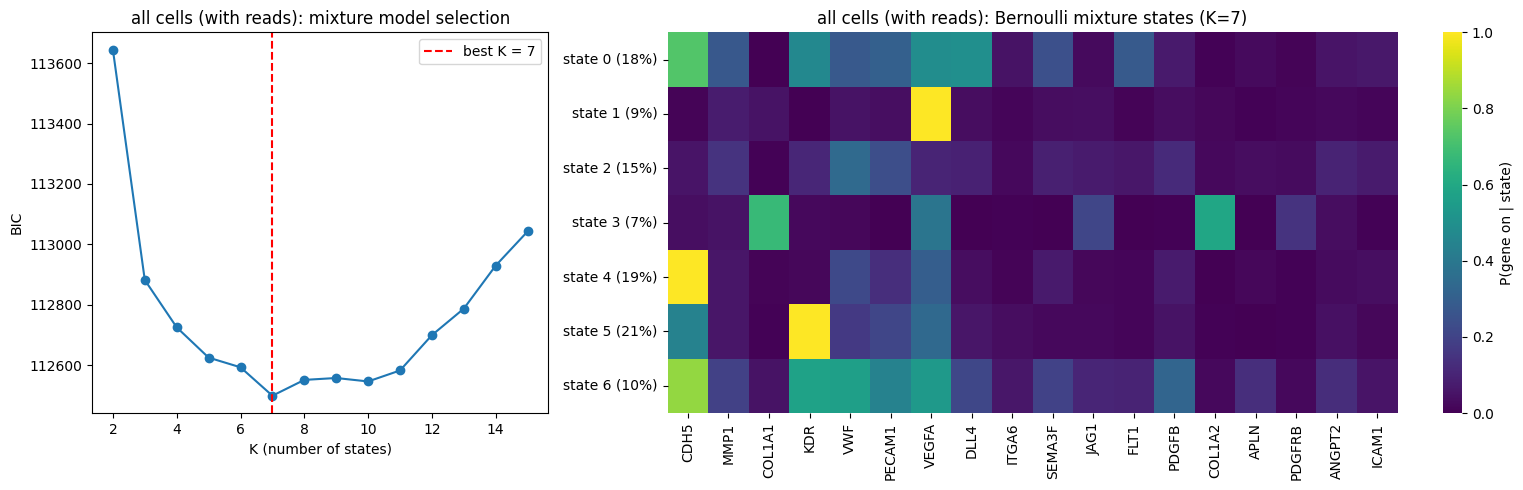

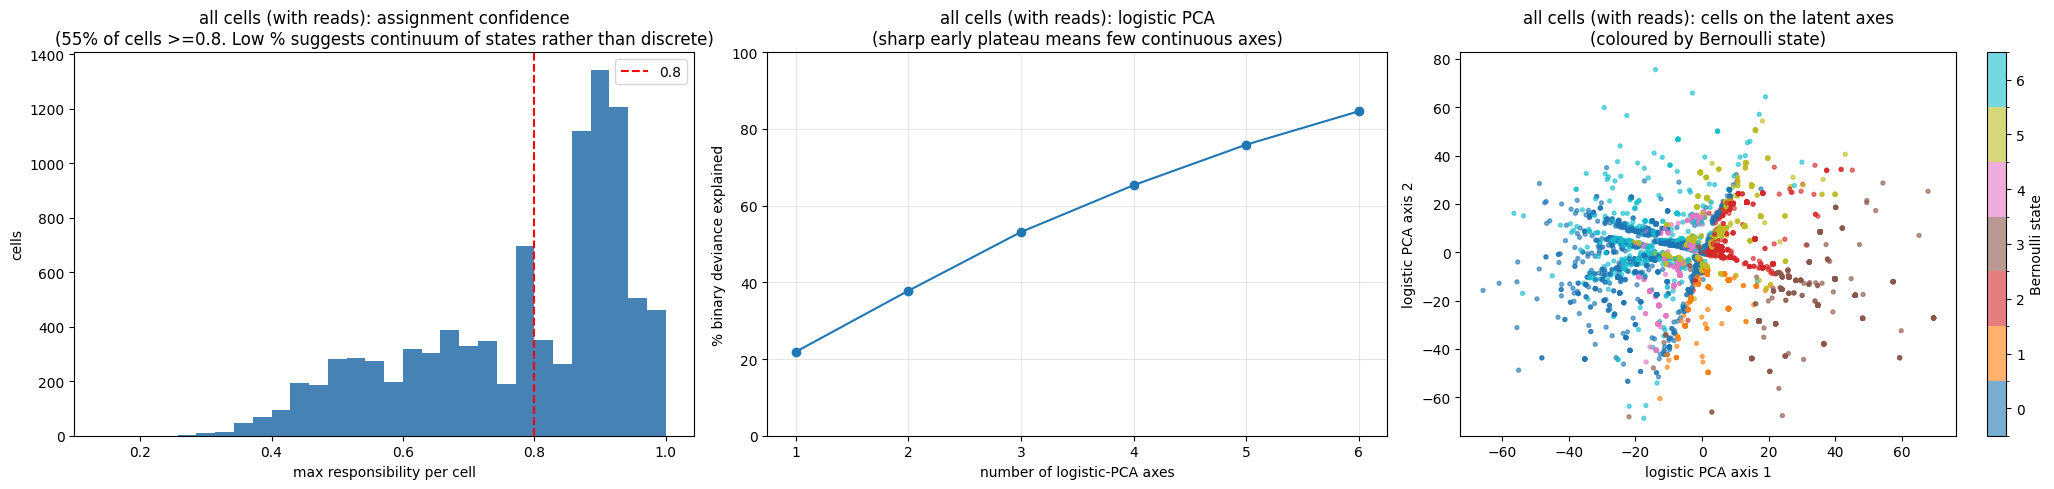

In [ ]:
# ============================================================================
# RUN SECTION 2 - Bernoulli mixture + logistic PCA on three population scopes:
#   (a) the WHOLE population (all-0-read cells excluded),
#   (b) endothelial (all cells), and (c) fibroblast (all cells).
# ============================================================================
MAX_CLUSTERS = 10
CELL_TYPES = ["endothelial", "fibroblast"]  # lineages carried into section 3

# Section 3 reads these per-cell columns; the per-lineage 'all cells' runs below fill
# them (bmm offset so the two lineages keep distinct ids). Reset them first.
df["bmm"] = -1
df["bmm_confidence"] = np.nan
df["lpca1"] = np.nan
df["lpca2"] = np.nan

# (a) WHOLE population - every cell with >=1 read, both lineages + unknown together.
# It overlaps the per-lineage runs, so its labels are NOT stored back to df.
res_pop = cluster_and_report(df, "all cells (with reads)", max_clusters=15)

POPULATION: endothelial (all cells)  (7,388 cells with reads)
Marker genes excluded from clustering (still define lineage): CDH5, VWF, PECAM1
Bernoulli BIC picked K = 4 states.

4 clusters identified for endothelial (all cells) cells (Bernoulli, 7,388 cells):
  cluster 3 (4,589 cells, 62%): likely states include 14% 1 (CDH5); 10% 4 (KDR); 6% 1_4 (CDH5, KDR)
  cluster 0 (1,383 cells, 19%): likely states include 14% 1_4_7 (CDH5, KDR, VEGFA); 13% 4_7 (KDR, VEGFA); 5% 1_4_5_7 (CDH5, KDR, VWF, VEGFA)
  cluster 2 (1,092 cells, 15%): likely states include 3% 1_7_8 (CDH5, VEGFA, DLL4); 1% 1_2_4_7_8 (CDH5, MMP1, KDR, VEGFA, DLL4); 1% 1_5_7_8 (CDH5, VWF, VEGFA, DLL4)
  cluster 1 (324 cells, 4%): likely states include 2% 1_7_8_13 (CDH5, VEGFA, DLL4, PDGFB); 2% 1_5_7_10_13 (CDH5, VWF, VEGFA, SEMA3F, PDGFB); 1% 1_7_10_13 (CDH5, VEGFA, SEMA3F, PDGFB)

Assignment discreteness (Bernoulli responsibilities, K=4):
  mean max-responsibility  : 0.702   (1 = every cell sits in one state)
  cells with max-re

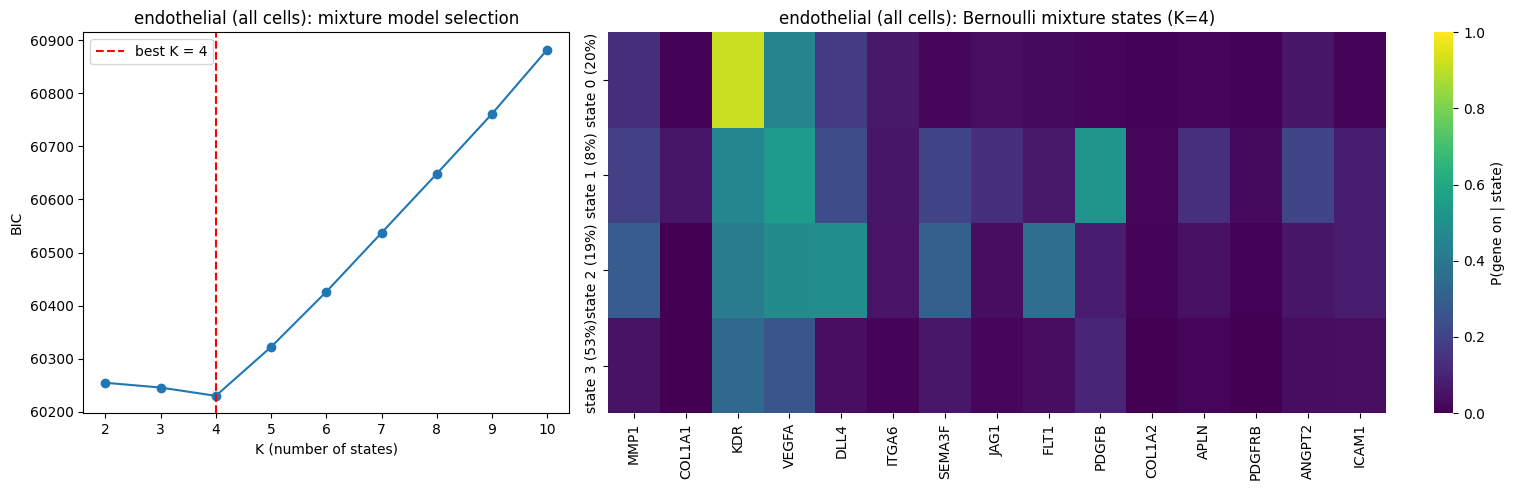

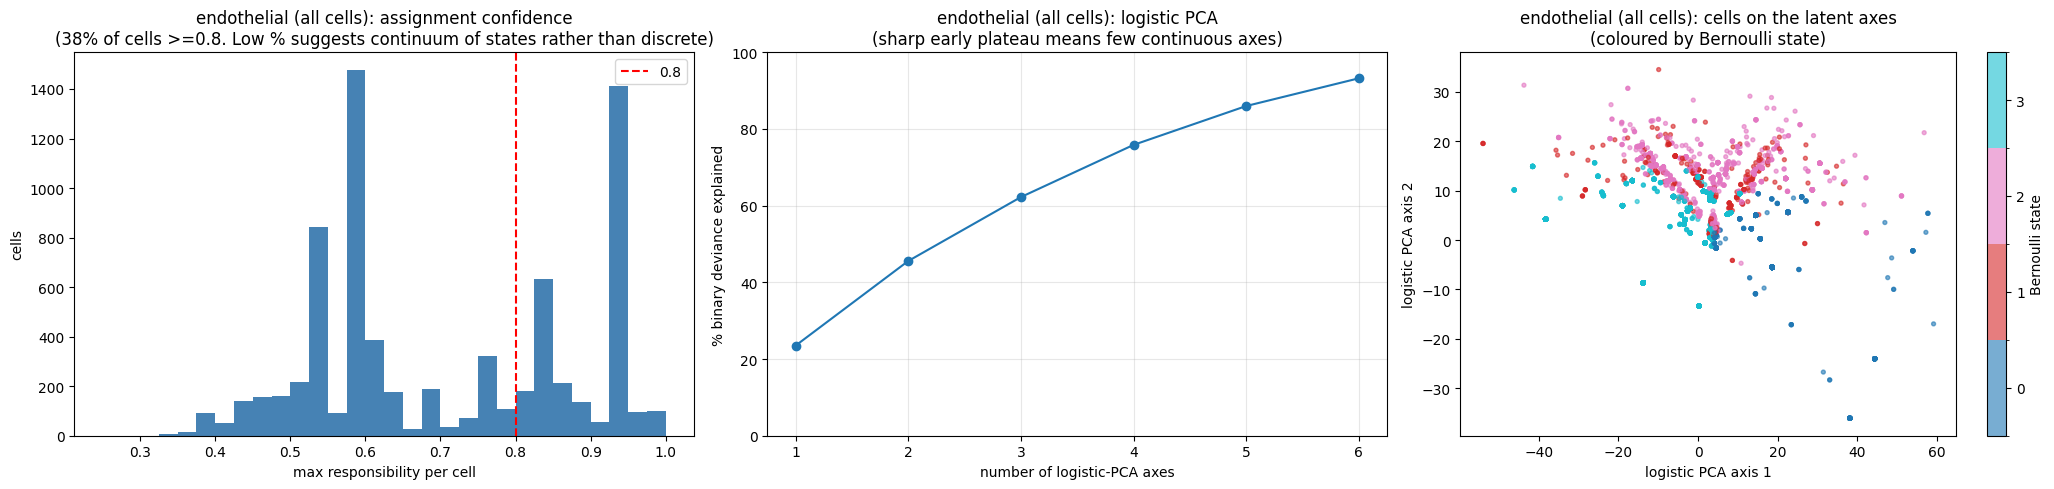

In [48]:
# (b) ENDOTHELIAL - all endothelial cells with reads (the lineage we suspect is a
# continuum). Stored back to df for the downstream neighbourhood analysis.
# CDH5/VWF/PECAM1 define the lineage upstream, so exclude them from the clustering.
res_endo_all = cluster_and_report(
    df[df.cell_type == "endothelial"], "endothelial (all cells)",

    max_clusters=MAX_CLUSTERS, store_to_df=True,    exclude_genes=["CDH5", "VWF", "PECAM1"])

In [49]:
# Name the endothelial logistic-PCA axes: which genes pull each end apart.
# Turns "axis 1 / axis 2" on the right-hand scatter into biology (e.g. angiogenic vs core).
endo_loadings = pd.DataFrame(
    res_endo_all["lpca_by_k"][2]["loadings"], index=res_endo_all["genes"], columns=["axis 1", "axis 2"])
for axis in ["axis 1", "axis 2"]:
    ranked = endo_loadings[axis].sort_values()
    pos_end = ", ".join(ranked.tail(4).index[::-1])   # genes at the + end
    neg_end = ", ".join(ranked.head(4).index)         # genes at the - end
    print(f"{axis}:  + end = {pos_end}   <-->   - end = {neg_end}")
display(endo_loadings.round(2).sort_values("axis 1"))

axis 1:  + end = KDR, VEGFA, ITGA6, DLL4   <-->   - end = PDGFB, ICAM1, SEMA3F, PDGFRB
axis 2:  + end = VEGFA, SEMA3F, FLT1, DLL4   <-->   - end = KDR, ITGA6, COL1A2, ANGPT2


,axis 1,axis 2
PDGFB,-0.06,0.11
SEMA3F,-0.02,0.26
ICAM1,-0.02,0.13
PDGFRB,0.00,0.07
APLN,0.01,0.10
COL1A1,0.01,0.07
JAG1,0.02,0.08
ANGPT2,0.02,0.07
FLT1,0.02,0.18
MMP1,0.03,0.13


### Reading the two leftmost panels

**Left panel - assignment confidence (histogram).**
- **x-axis (`max responsibility per cell`):** how sure the model was when it placed each
  cell into a group. `1.0` = "this cell clearly belongs to one group"; the far left
  (`1/number-of-groups`) = "it's an even toss-up between several groups".
- **y-axis (`cells`):** how many cells sit at each confidence level.
- **Red dashed line (`0.8`):** the cutoff we call "confidently sorted"; the title reports
  the % of cells to its right.
- **How to read it:** a tall pile bunched against `1.0` means cells commit cleanly to one
  group -> **distinct types**. A long spread reaching left (lots of cells below `0.8`)
  means many cells are borderline, sitting between groups -> **continuum**. Endothelial
  shows exactly this leftward tail.

**Middle panel - logistic PCA "dials" curve.**
- **x-axis (`number of logistic-PCA axes`):** how many underlying continuous "dials" we
  allow the model to use.
- **y-axis (`% binary deviance explained`):** how much of the whole on/off pattern those
  dials manage to reconstruct (0% = nothing, 100% = perfectly).
- **How to read it:** if the line shoots up and then **flattens after 1-2 dials**, a couple
  of smooth gradients explain almost everything -> a **continuum along a few axes**. If it
  keeps **climbing steadily** with no plateau (endothelial rises ~15% per dial, needing ~6
  to reach ~84%), then no single gradient dominates - the variation is spread across many
  small, independent programmes. A quick early plateau (fibroblast) signals simpler,
  more discrete structure.

POPULATION: fibroblast (all cells)  (732 cells with reads)
Marker genes excluded from clustering (still define lineage): COL1A1, COL1A2
Bernoulli BIC picked K = 2 states.

2 clusters identified for fibroblast (all cells) cells (Bernoulli, 732 cells):
  cluster 0 (720 cells, 98%): likely states include 14% 3_14 (COL1A1, COL1A2); 11% 3 (COL1A1); 11% 14 (COL1A2)
  cluster 1 (12 cells, 2%): likely states include 8% 2_7_8_9_16 (MMP1, VEGFA, DLL4, ITGA6, PDGFRB); 8% 2_8_14_17 (MMP1, DLL4, COL1A2, ANGPT2); 8% 7_8_10_16 (VEGFA, DLL4, SEMA3F, PDGFRB)

Assignment discreteness (Bernoulli responsibilities, K=2):
  mean max-responsibility  : 0.984   (1 = every cell sits in one state)
  cells with max-resp >=0.8: 98.8%
  mean normalised entropy  : 0.079   (0 = discrete, 1 = evenly spread across states)

Logistic PCA - fraction of binary deviance explained by the first n axes:
  1 axis  :  39.9%
  2 axises:  69.5%
  3 axises:  88.6%
  4 axises:  95.2%
  5 axises:  98.3%
  6 axises:  98.8%



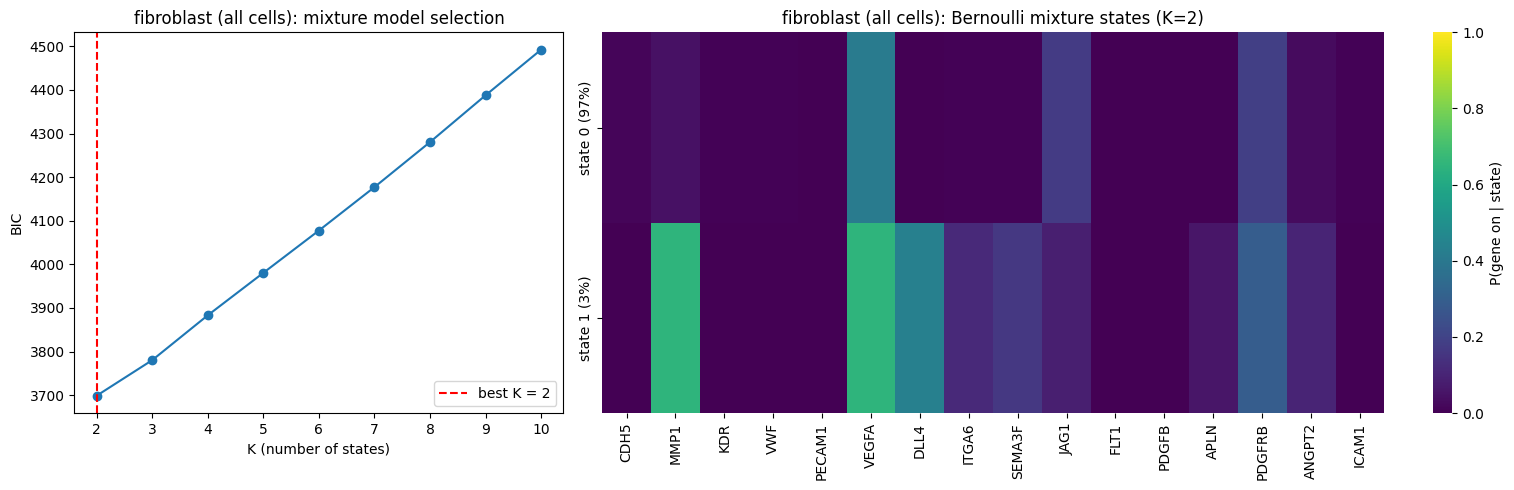

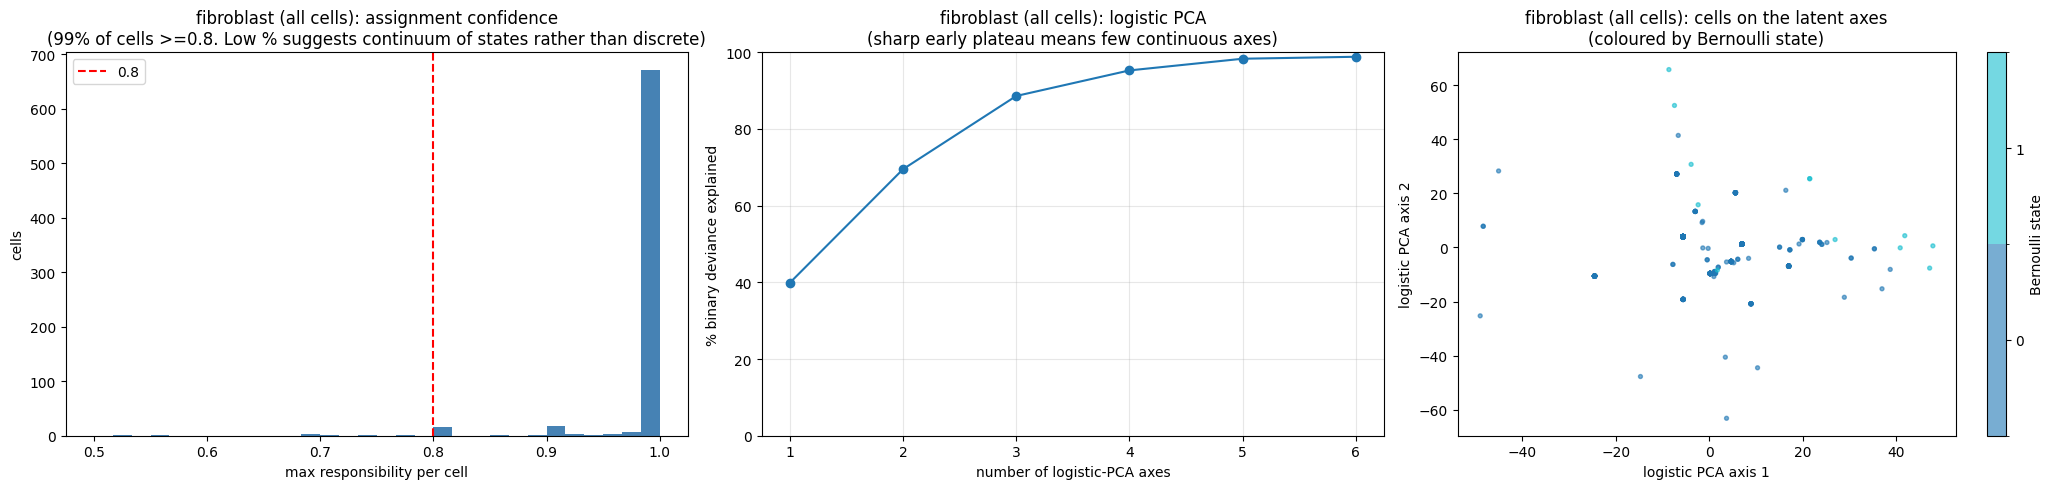

In [50]:
# (c) FIBROBLAST - all fibroblast cells with reads.
# Stored back to df for the downstream neighbourhood analysis.
# COL1A1/COL1A2 define the lineage upstream, so exclude them from the clustering.
res_fibro_all = cluster_and_report(
    df[df.cell_type == "fibroblast"], "fibroblast (all cells)",
    max_clusters=MAX_CLUSTERS, store_to_df=True,

    exclude_genes=["COL1A1", "COL1A2"])

In [51]:
# Collect every run's cluster summary into one tidy table.
all_runs = [res_pop, res_endo_all, res_fibro_all]
cluster_overview = pd.concat([r["summaries"] for r in all_runs if r is not None],
                             ignore_index=True)
cluster_overview.to_csv(output_dir / "section2_cluster_overview.csv", index=False)
print("Saved -> section2_cluster_overview.csv")


Saved -> section2_cluster_overview.csv


### Are the gene-state clusters "real" in tissue?

The clusters above were found from gene expression alone, ignoring where the cells sit.
If a cluster is a genuine biological state (not just a statistical slice of a continuum),
its cells should tend to **occupy the same tissue territory** rather than being scattered
at random. We test this directly in space using the per-cell cluster labels stored in
`df["bmm"]`.

For each pair of clusters we count how often their cells are spatial neighbours (within
30 um, in the same image), then compare to a **shuffled null** where cluster labels are
randomly permuted within each image. The result is a z-score matrix:

- **Diagonal z > 0** - a cluster's own cells sit next to each other more than chance, i.e.
  the cluster forms real spatial patches (evidence it is a genuine state).
- **Off-diagonal z > 0** - two different clusters are neighbours more than chance (e.g.
  endothelial cluster 2 tends to sit beside fibroblast cluster 1), revealing which states
  organise together in tissue.

The map on the right shows one image coloured by cluster so the patches can be eyeballed.

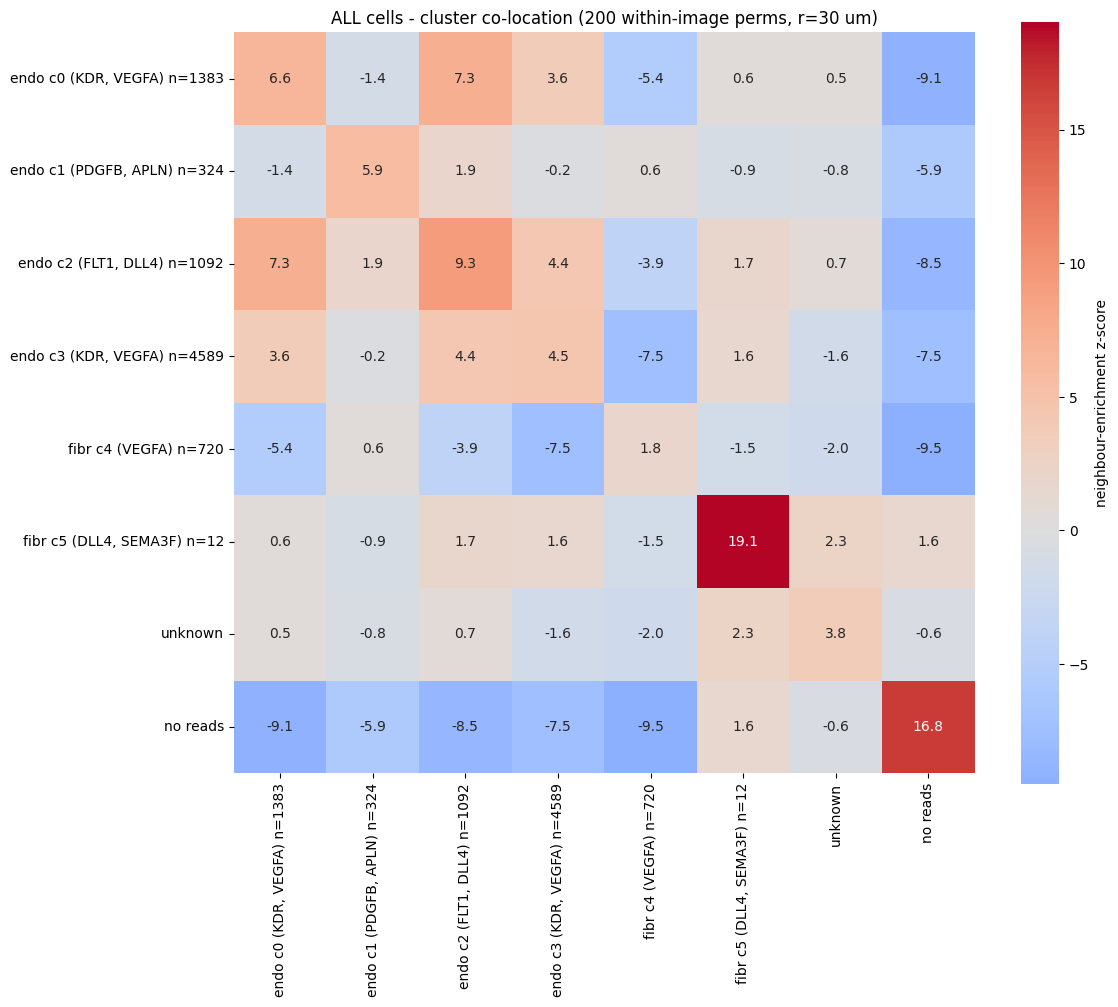

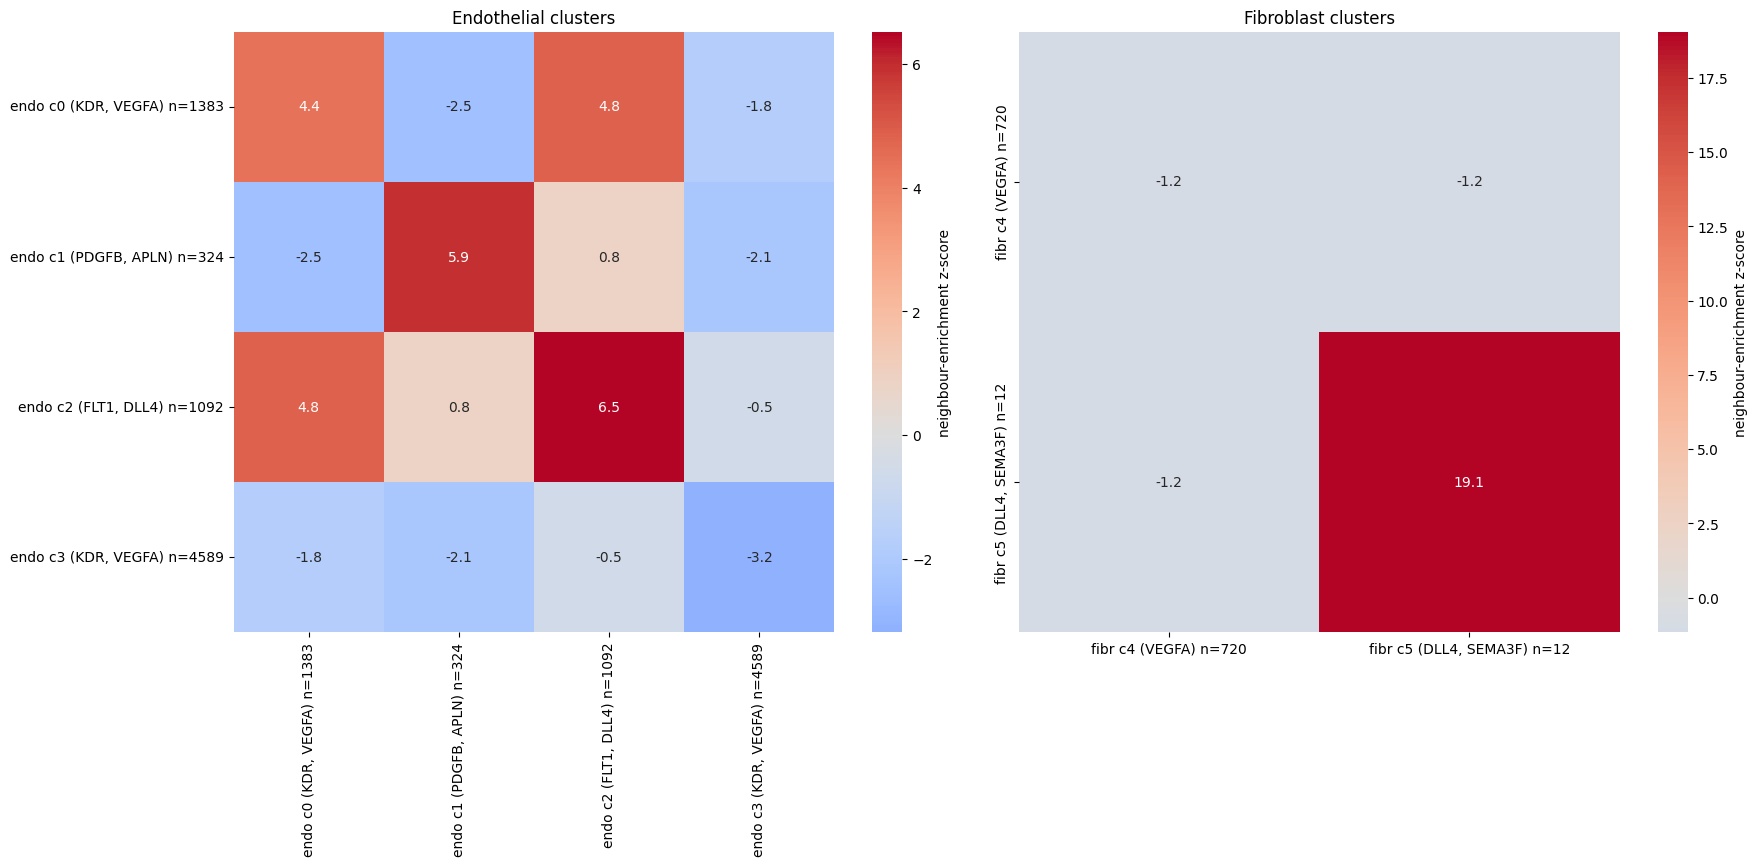

Same-cluster spatial cohesion (diagonal z-score from the ALL-cells test; higher = sits together):
  z =  +6.6   endo c0 (KDR, VEGFA) n=1383
  z =  +5.9   endo c1 (PDGFB, APLN) n=324
  z =  +9.3   endo c2 (FLT1, DLL4) n=1092
  z =  +4.5   endo c3 (KDR, VEGFA) n=4589
  z =  +1.8   fibr c4 (VEGFA) n=720
  z = +19.1   fibr c5 (DLL4, SEMA3F) n=12


In [81]:
# ==========================================================================
# ARE THE GENE-STATE CLUSTERS "REAL" IN SPACE?
# Uses the per-cell Bernoulli cluster id in df["bmm"] (endothelial + fibroblast runs,
# offset so ids are distinct; -1 = cell not clustered -> "unknown" lineage or "no reads"
# all-0 cell). A within-image label-shuffling permutation test asks:
#   (1) Diagonal z > 0     -> a cluster's cells sit NEXT TO EACH OTHER more than chance.
#   (2) Off-diagonal z > 0 -> two clusters are neighbours more than chance.
# Heatmaps: ALL cells together, then endothelial-only and fibroblast-only. Per-cell spatial
# maps of the clusters vs niches are drawn together in the neighbourhood section below.
# ==========================================================================
SPATIAL_RADIUS_UM = 30.0     # two cells are "neighbours" if within this distance (same image)
N_PERM = 200

clustered = df[df["bmm"] >= 0].reset_index(drop=True)
cluster_ids = np.sort(clustered["bmm"].unique())

# Genes actually used for each lineage's clustering (the marker genes were excluded upstream).
genes_by_lineage = {}
for r in (res_endo_all, res_fibro_all):
    if r is not None:
        genes_by_lineage[r["cells"]["cell_type"].mode().iat[0]] = r["genes"]

# Name a cluster by its most UPREGULATED non-excluded genes (highest ON-fraction vs the
# lineage baseline). Excluded marker genes (CDH5/VWF/PECAM1, COL1A1/COL1A2) never appear.
def _cluster_top_genes(sub, lineage, n_top=2, min_on=0.2):
    genes_here = genes_by_lineage.get(lineage, GENES)
    cluster_on = sub[genes_here].mean()
    baseline_on = clustered.loc[clustered["cell_type"] == lineage, genes_here].mean()
    enrichment = (cluster_on / (baseline_on + 1e-9))[cluster_on >= min_on].sort_values(ascending=False)
    if enrichment.empty:                       # backbone cluster with nothing extra switched on
        enrichment = cluster_on.sort_values(ascending=False)
    return ", ".join(enrichment.head(n_top).index)

cluster_lineage, cluster_name_of = {}, {}
for c in cluster_ids:
    sub = clustered[clustered["bmm"] == c]
    lin = sub["cell_type"].mode().iat[0]
    cluster_lineage[c] = lin
    cluster_name_of[c] = f"{lin[:4]} c{c} ({_cluster_top_genes(sub, lin)}) n={len(sub)}"
cluster_names = [cluster_name_of[c] for c in cluster_ids]
endo_names = [cluster_name_of[c] for c in cluster_ids if cluster_lineage[c] == "endothelial"]
fibro_names = [cluster_name_of[c] for c in cluster_ids if cluster_lineage[c] == "fibroblast"]

# Per-cell display group: cluster name, else "unknown" lineage or "no reads" (all-0 cell).
group = df["bmm"].map(cluster_name_of)
group = group.where(df["bmm"] >= 0, np.where(df["had_reads"], "unknown", "no reads"))
df_disp = df.assign(group=group)


# --- Reusable within-image neighbour-enrichment permutation test + heatmap ---
def neighbour_enrichment(cells, order, title, ax, radius=SPATIAL_RADIUS_UM, n_perm=N_PERM, seed=0):
    cells = cells[cells["group"].isin(order)].reset_index(drop=True)
    pos = {g: i for i, g in enumerate(order)}
    code = cells["group"].map(pos).to_numpy()
    image_positions = [g.index.to_numpy() for _, g in cells.groupby(IMAGE_KEY)]
    edges = []
    for pidx in image_positions:
        coords = cells.loc[pidx, ["x_um", "y_um", "z_um"]].to_numpy()
        tree = cKDTree(coords)
        for a, b in tree.query_pairs(radius):
            edges.append((pidx[a], pidx[b]))
    E = np.array(edges)
    n = len(order)

    def _counts(lbl):
        m = np.zeros((n, n))
        if len(E):
            for u, v in zip(lbl[E[:, 0]], lbl[E[:, 1]]):
                m[u, v] += 1
                m[v, u] += 1
        return m

    def _shuffle(lbl, generator):
        out = lbl.copy()
        for pidx in image_positions:
            out[pidx] = generator.permutation(lbl[pidx])
        return out

    obs = _counts(code)
    generator = np.random.default_rng(seed)
    perm = np.stack([_counts(_shuffle(code, generator)) for _ in range(n_perm)])
    zmat = (obs - perm.mean(0)) / (perm.std(0) + 1e-9)
    zdf = pd.DataFrame(zmat, index=order, columns=order)
    sns.heatmap(zdf, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
                ax=ax, cbar_kws={"label": "neighbour-enrichment z-score"})
    ax.set_title(title)
    return zdf


# (1) ALL cells together (clusters + unknown + all-0 "no reads").
all_order = cluster_names + ["unknown", "no reads"]
fig, ax = plt.subplots(figsize=(1.1 * len(all_order) + 3, 1.0 * len(all_order) + 2))
z_all = neighbour_enrichment(df_disp, all_order,
                             f"ALL cells - cluster co-location ({N_PERM} within-image perms, "
                             f"r={SPATIAL_RADIUS_UM:.0f} um)", ax)
plt.tight_layout(); plt.show()

# (2) Endothelial-only and (3) fibroblast-only (clusters within each lineage).
fig, axes = plt.subplots(1, 2, figsize=(9 * 2, 8))
neighbour_enrichment(df_disp[df_disp["cell_type"] == "endothelial"], endo_names,
                     "Endothelial clusters", axes[0])
neighbour_enrichment(df_disp[df_disp["cell_type"] == "fibroblast"], fibro_names,
                     "Fibroblast clusters", axes[1])
plt.tight_layout(); plt.show()


print("Same-cluster spatial cohesion (diagonal z-score from the ALL-cells test; higher = sits together):")
for nm in cluster_names:
    print(f"  z = {z_all.loc[nm, nm]:+5.1f}   {nm}")

'no reads' cells: 3,575 of 13,047 (27.4%)

Median per group (no reads vs has reads):
          edge_dist_um  z_frac  local_density
no_reads                                     
False           118.74    0.50            3.0
True            107.59    0.57            3.0 



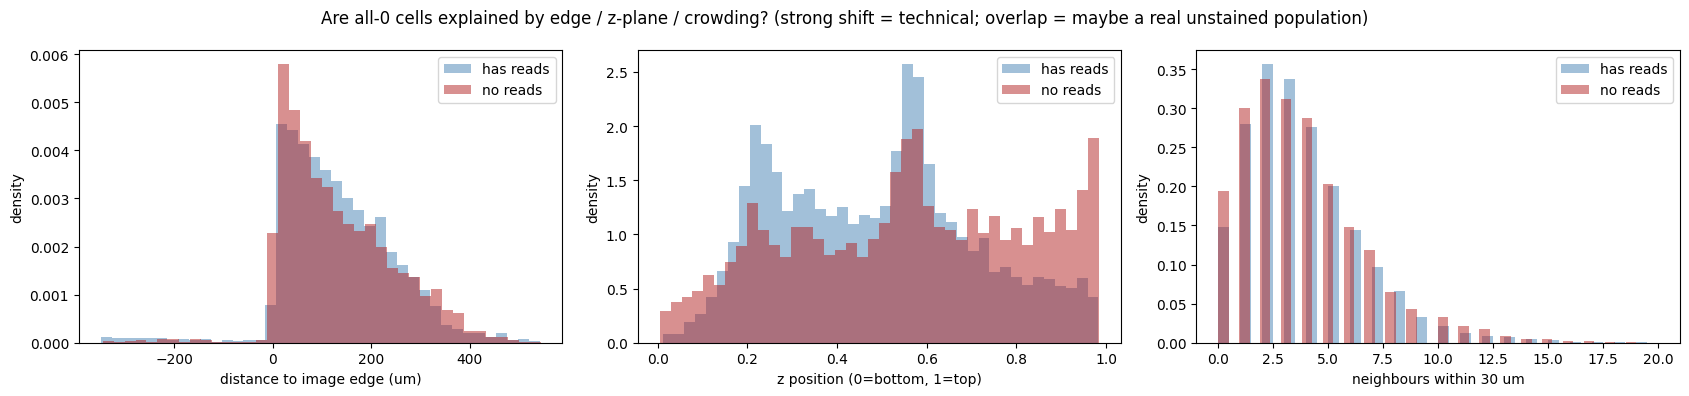

In [ ]:
    # ==========================================================================
# QC: are the "no reads" (all-0) cells a TECHNICAL artefact or a real population?
# Technical dropout tends to be REGIONAL and to correlate with proximity to the image
# EDGE, extreme Z-planes, and local CROWDING (over-segmentation). We compare all-0 cells
# to cells-with-reads on these three axes. If no-reads cells pile up at edges / z-extremes
# / high density, the strong no-reads<->no-reads spatial co-location is most likely a
# technical failure; if their distributions overlap the with-reads cells, it points more
# to a genuine population negative for all 18 panel genes.
# ==========================================================================
qc = df.copy()
qc["no_reads"] = ~qc["had_reads"]

# Distance to the nearest XY image edge (microns) and z-plane position (0=bottom, 1=top).
qc["edge_dist_um"] = np.minimum.reduce([
    qc["nucleus_centroid_x"], qc["Xmax"] - qc["nucleus_centroid_x"],
    qc["nucleus_centroid_y"], qc["Ymax"] - qc["nucleus_centroid_y"]]) * XY_UM
qc["z_frac"] = qc["nucleus_centroid_z"] / qc["Zmax"]

# Local neighbour count within 30 um (crowding), computed within each image.
local_density = np.zeros(len(qc))
for _, sub in qc.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    local_density[ii] = [len(x) - 1 for x in tree.query_ball_point(coords, 30.0)]
qc["local_density"] = local_density

metrics = ["edge_dist_um", "z_frac", "local_density"]
print(f"'no reads' cells: {qc['no_reads'].sum():,} of {len(qc):,} ({100 * qc['no_reads'].mean():.1f}%)\n")
print("Median per group (no reads vs has reads):")
print(qc.groupby("no_reads")[metrics].median().round(2), "\n")

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
labels = {"edge_dist_um": "distance to image edge (um)", "z_frac": "z position (0=bottom, 1=top)",
          "local_density": "neighbours within 30 um"}
for a, col in zip(ax, metrics):
    for flag, colour in [(False, "steelblue"), (True, "firebrick")]:
        a.hist(qc.loc[qc.no_reads == flag, col], bins=40, density=True, alpha=0.5,
               color=colour, label="no reads" if flag else "has reads")
    a.set_xlabel(labels[col]); a.set_ylabel("density"); a.legend()
fig.suptitle("Are all-0 cells explained by edge / z-plane / crowding? "
             "(strong shift = technical; overlap = maybe a real unstained population)")
plt.tight_layout(); plt.show()

### Are the "no reads" cells technical? (QC result)

**27.4%** of segmented cells detect zero of the 18 panel genes, and earlier we saw these
all-0 cells co-locate strongly with each other. The QC above asks whether that is a
**technical dropout** signature on three axes:

- **Crowding / over-segmentation - ruled out.** No-reads and has-reads cells have an
  *identical* local density (median 3 neighbours within 30 um, fully overlapping histograms).
  So the all-0 cells are **not** just over-segmented fragments in dense regions.
- **Image edge - minor.** No-reads cells sit slightly closer to the field edge (median 108 vs
  119 um) but the distributions overlap almost entirely - a weak effect at most.
- **Z-plane - the one real technical signal.** No-reads cells are **enriched toward the top of
  the stack** (median z-fraction 0.57 vs 0.50, with a clear excess in the top planes). This is
  the classic depth-dependent hybridisation/imaging drop-off, where upper (or optically worse)
  planes lose signal.

**Interpretation.** The strong no-reads<->no-reads co-location is **at least partly technical**
- driven by a z-depth dropout gradient, not by crowding. But the large overlap with has-reads
cells on every axis means it is **not fully explained** by these artefacts, so a subset may be
genuinely panel-negative cells. Either way, the all-0 cells should **not** be read as a real
biological "programme"; they are correctly kept flagged and excluded from the gene-state and
module analyses.

### How to read the continuum diagnostics

The three outputs above converge on the same question - **discrete types or a continuum?**

- **Bernoulli states (heatmap).** If states have clean, near-0/1 on-probabilities and
  differ by whole blocks of genes, they look like real types. Graded columns that only
  shift a few probabilities suggest a continuum sampled at K points.
- **Assignment confidence (max-responsibility histogram).** A spike near 1.0 (most cells
  >=0.8) means cells commit to one state -> **discrete**. A mass at low values, or a broad
  spread, means cells are shared between states -> **continuum**. The mean normalised
  entropy printed above says the same thing (0 = discrete, 1 = evenly mixed).
- **Logistic PCA (deviance-explained curve).** If 1-2 axes already explain most of the
  binary deviance and the curve then flattens, the K states collapse onto a **few
  continuous axes** - strong continuum evidence. A slow, steady climb needing many axes
  argues instead for several genuinely distinct programmes.
- **Latent-axis scatter.** Discrete types show as separated clouds; a continuum shows one
  elongated cloud that the Bernoulli colours cut into arbitrary slices.

We expect **fibroblasts** to look discrete (high confidence, few axes, separated clouds)
and **endothelial** cells to look like a continuum (lower confidence, an elongated latent
cloud whose main axis is the `KDR`/`VEGFA` angiogenic gradient).

### Conclusions - gene states & their spatial reality

**Approach.** Bernoulli mixture (recurring states) + responsibilities (how discrete each
assignment is) + logistic PCA (can a few continuous axes explain it?), then a within-image
label-shuffling permutation test asking whether each state's cells sit together in tissue.

**Assumptions / drawbacks.** All-0-read cells were split into lineages artificially and
carry no state (flagged, never clustered). The permutation z-scores need enough cells per
image; tiny clusters (e.g. the n=12 fibroblast state with a huge z) are unreliable. "State"
is a soft label on what is, for endothelial cells, largely a continuum.

**Biology.**
- **Endothelial = a structured continuum**, not discrete types (Bernoulli, responsibilities
  and logistic PCA all agree). The main axis is `KDR`/`VEGFA` angiogenic activation on a
  `CDH5` backbone, with a `DLL4`/`FLT1`/`MMP1` tip/sprouting flavour.
- **Fibroblasts = a few genuinely discrete states** (high confidence, fast PCA plateau).
- **Are the states "real" in space?** The angiogenic endothelial states form genuine
  spatial patches (diagonal z ~ 6-9) - distinct tissue territory. The plain `CDH5`-only
  backbone is spatially diffuse (low z), as expected for a shared baseline. Collagen
  fibroblasts sit *apart* from the angiogenic endothelium (negative off-diagonal), not
  intermixed.

**Do the methods agree?** Yes - the three discrete-vs-continuum diagnostics agree per
lineage, and the independent spatial test confirms that the *functional* endothelial states
(not the backbone) are spatially organised.

## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**,
which we relate back to gene state - and we then test whether whole gene states
(e.g. `1_4_7` vs `1_4_8`) co-locate in space.


In [52]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% endothelial / fibroblast / unknown)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within a fixed radius)


K_SPATIAL = 15         # neighbours used for composition / expression
RADIUS_UM = 30.0       # radius (microns) used for the local-density count

ct_dummies = (pd.get_dummies(df["cell_type"])
              .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

feat_ct   = np.zeros((len(df), len(CT_ORDER)))
feat_gene = np.zeros((len(df), len(GENES)))
entropy   = np.zeros(len(df))
density   = np.zeros(len(df))

for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb   # drop self column
    gneigh = ii[neigh]                             # local -> global indices
    feat_ct[ii]   = ct_dummies[gneigh].mean(axis=1)
    feat_gene[ii] = X[gneigh].mean(axis=1)
    comp = feat_ct[ii]
    entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
    density[ii] = np.array([len(x) - 1 for x in tree.query_ball_point(coords, RADIUS_UM)])

nbhd = pd.DataFrame(feat_ct, columns=[f"nb_%{c}" for c in CT_ORDER], index=df.index)
nbhd = pd.concat(
    [nbhd, pd.DataFrame(feat_gene, columns=[f"nb_{g}" for g in GENES], index=df.index)],
    axis=1)
nbhd["nb_entropy"] = entropy
nbhd["nb_density"] = density
df[nbhd.columns] = nbhd


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_341584\3404930806.py:32: RuntimeWarning: divide by zero encountered in log
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_341584\3404930806.py:32: RuntimeWarning: invalid value encountered in multiply
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)


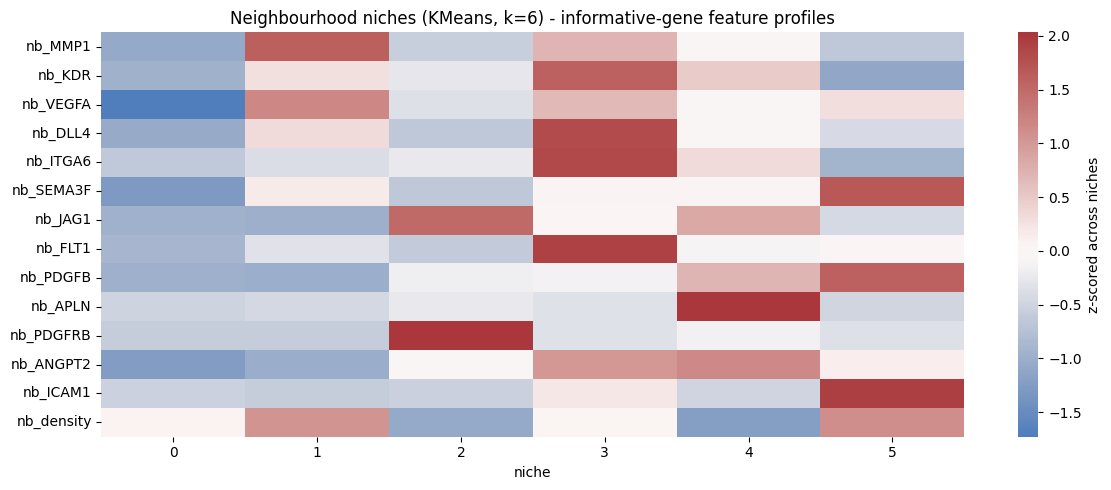

In [82]:
# Cluster the NEIGHBOURHOODS into recurring micro-environments ("niches"). The population
# is overwhelmingly endothelial, so cell-type composition, its Shannon entropy (which just
# measure "endothelial vs mixed"), and the lineage-defining markers dominate any clustering
# that includes them - niches then collapse onto an uninteresting endothelial-density axis.
# We therefore build niches from the NEIGHBOURHOOD EXPRESSION of the informative
# (non-marker) genes only, so niches reflect functional gene micro-environments.
NICHE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1", "COL1A1", "COL1A2"}
niche_genes = [g for g in GENES if g not in NICHE_MARKER_EXCLUDE]
nb_feature_cols = [f"nb_{g}" for g in niche_genes] + ["nb_density"]
Zf = StandardScaler().fit_transform(df[nb_feature_cols].values)

n_niches = 6
df["niche"] = KMeans(n_clusters=n_niches, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche (z-scored across niches so genes and density are comparable).
niche_profile = df.groupby("niche")[nb_feature_cols].mean()
niche_profile_z = (niche_profile - niche_profile.mean()) / (niche_profile.std() + 1e-9)
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile_z.T, cmap="vlag", center=0,
            cbar_kws={"label": "z-scored across niches"})
plt.title(f"Neighbourhood niches (KMeans, k={n_niches}) - informative-gene feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()

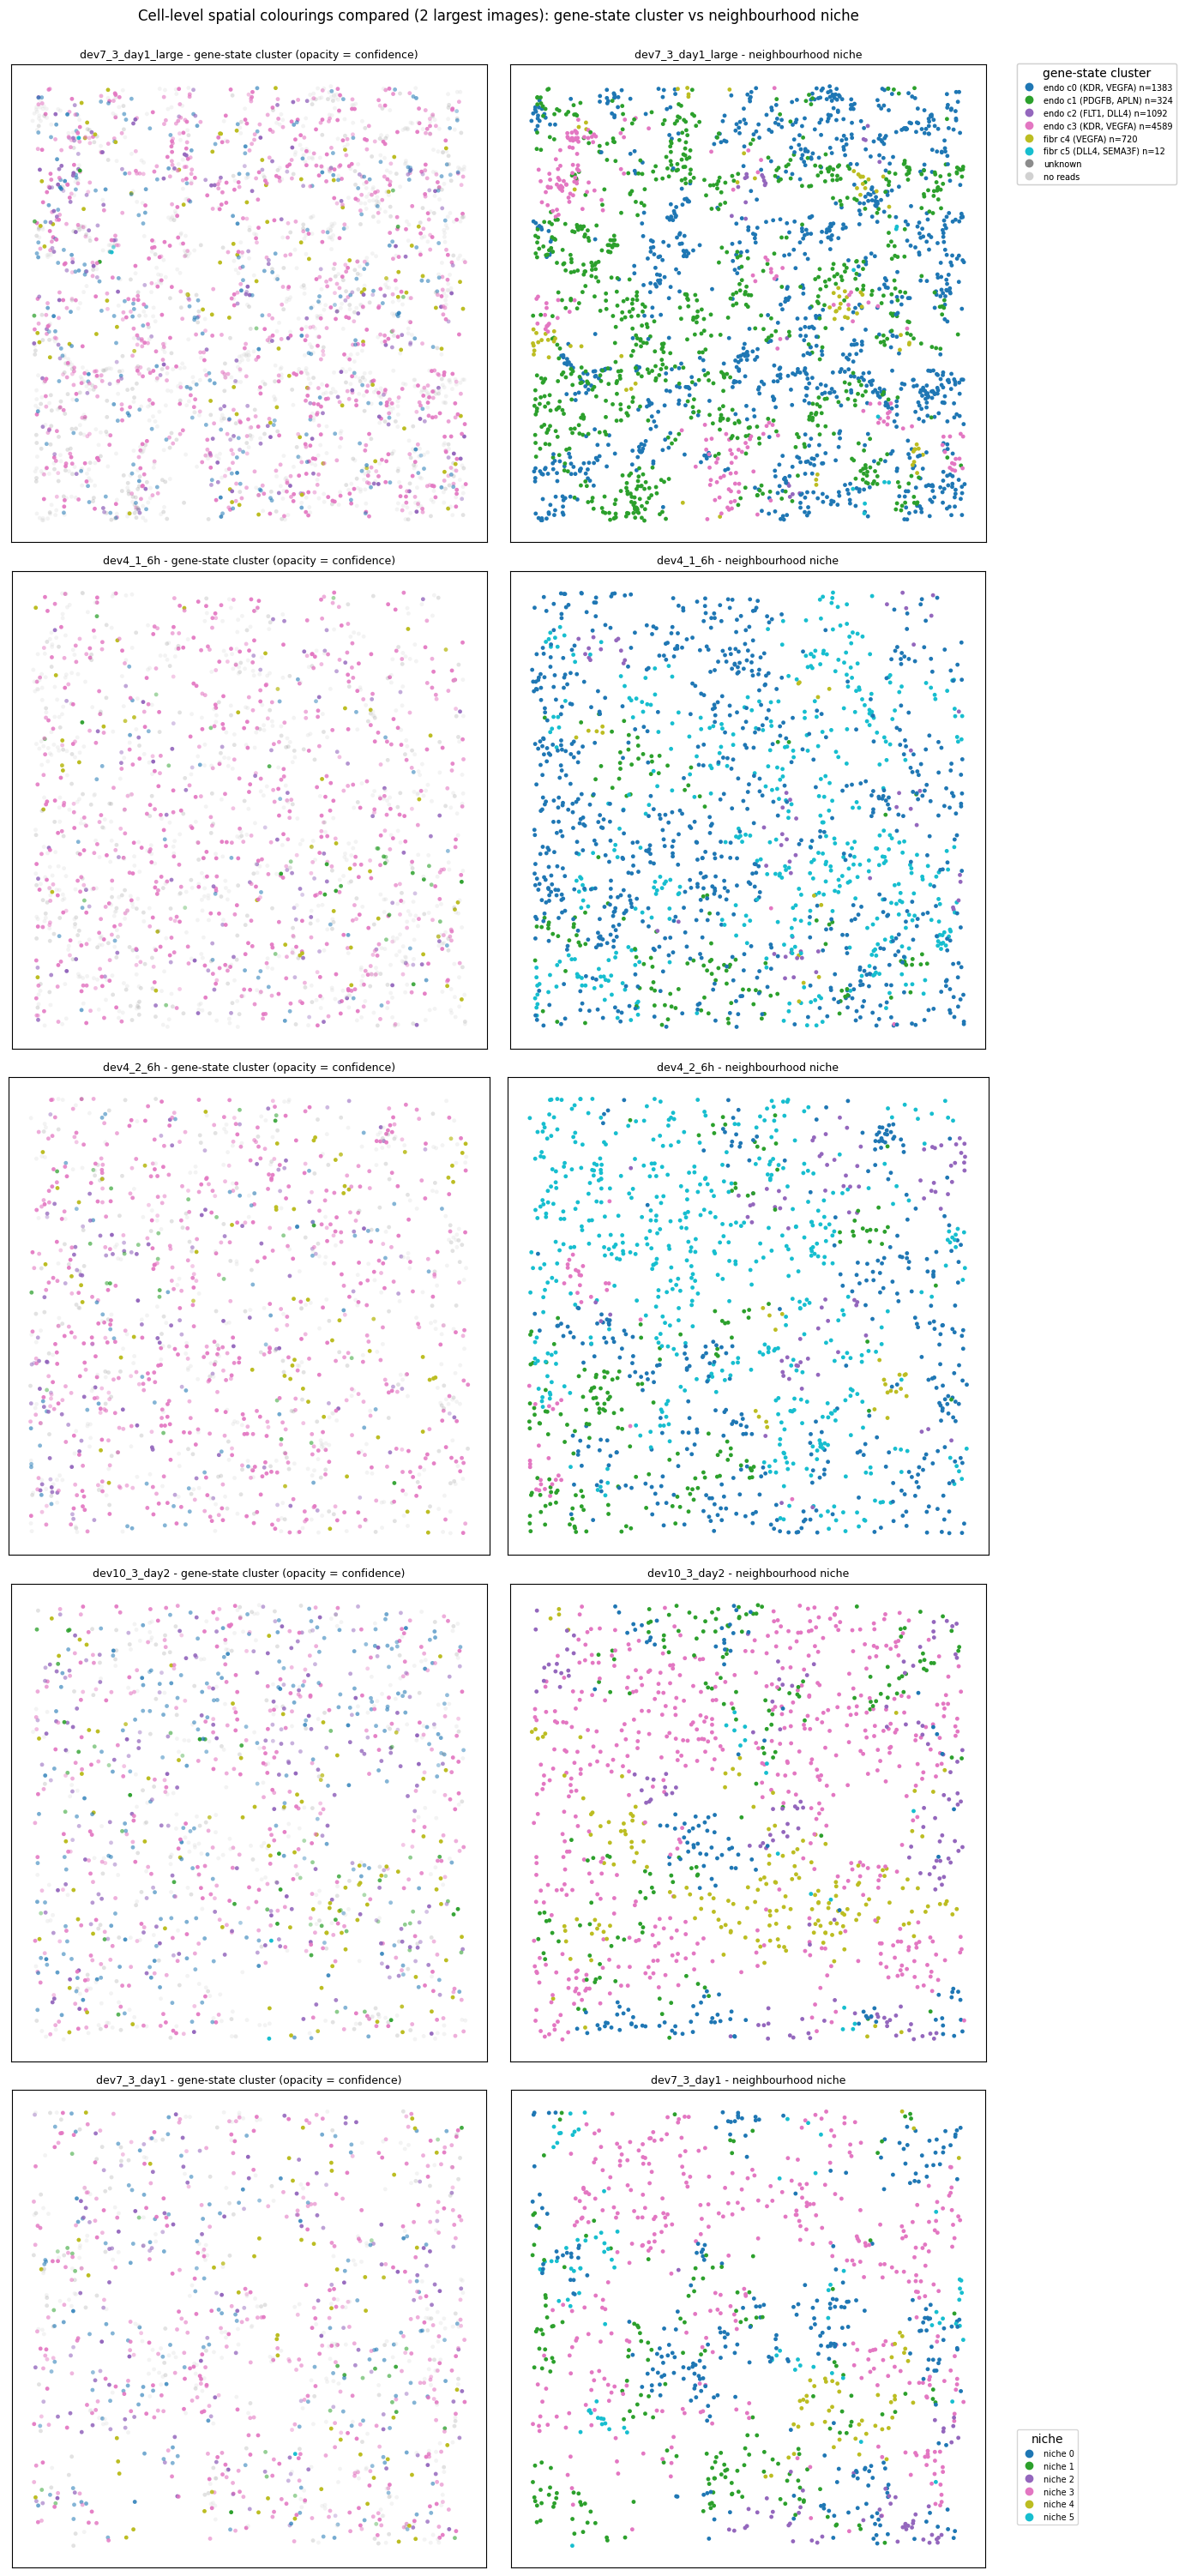

In [ ]:

# Gene-state cluster colours (opacity = assignment confidence; grey = unknown / no reads).
cluster_cmap = plt.get_cmap("tab10", len(cluster_names))
cluster_palette = {name: to_rgba(cluster_cmap(i)) for i, name in enumerate(cluster_names)}
cluster_palette["unknown"] = to_rgba("0.55")
cluster_palette["no reads"] = to_rgba("0.82")

# Neighbourhood niche colours.
niche_ids = np.sort(df["niche"].unique())
niche_cmap = plt.get_cmap("tab10", len(niche_ids))
niche_color = {nid: niche_cmap(i) for i, nid in enumerate(niche_ids)}

two_images = df_disp[IMAGE_KEY].value_counts().head(5).index.tolist()
fig, axes = plt.subplots(len(two_images), 2, figsize=(12, 6 * len(two_images)), squeeze=False)
for row, image_name in enumerate(two_images):
    sub = df_disp[df_disp[IMAGE_KEY] == image_name]

    rgba = np.array([cluster_palette[g] for g in sub["group"]])
    conf = sub["bmm_confidence"].to_numpy(dtype=float)
    rgba[:, 3] = np.where(np.isnan(conf), 0.25, np.clip(conf, 0.05, 1.0))  # opacity = confidence
    axes[row, 0].scatter(sub["x_um"], sub["y_um"], s=12, c=rgba, edgecolors="none")
    axes[row, 0].set_title(f"{image_name} - gene-state cluster (opacity = confidence)", fontsize=9)

    axes[row, 1].scatter(sub["x_um"], sub["y_um"], s=12, edgecolors="none",
                         c=[niche_color[n] for n in sub["niche"]])
    axes[row, 1].set_title(f"{image_name} - neighbourhood niche", fontsize=9)

    for col in (0, 1):
        axes[row, col].set_aspect("equal"); axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

cluster_handles = [Line2D([0], [0], marker="o", linestyle="", color=cluster_palette[name], label=name)
                   for name in all_order]
niche_handles = [Line2D([0], [0], marker="o", linestyle="", color=niche_color[nid], label=f"niche {nid}")
                 for nid in niche_ids]
leg1 = fig.legend(handles=cluster_handles, title="gene-state cluster", fontsize=7,
                  loc="upper left", bbox_to_anchor=(1.0, 0.98))
fig.add_artist(leg1)
fig.legend(handles=niche_handles, title="niche", fontsize=7,
           loc="lower left", bbox_to_anchor=(1.0, 0.02))
fig.suptitle("Cell-level spatial colourings compared (2 largest images): "
             "gene-state cluster vs neighbourhood niche", y=1.0)
plt.tight_layout(); plt.show()

### Conclusions - neighbourhood niches

**Approach.** Each cell is described by its k-nearest neighbours (same image): neighbourhood
gene expression and local density. Niches = KMeans on those features. We deliberately use
only the **informative (non-marker) genes** and drop cell-type composition + Shannon entropy,
because in a majority-endothelial sample those just encode "endothelial-dense vs mixed" and
swamp the functional signal.

**Assumptions / drawbacks.** The neighbour count k, the radius and the number of niches are
chosen, not learned; KMeans forces round, roughly equal clusters. Niches are partly circular
with the gene-state clusters (both use spatial neighbours).

**Biology.** The niches are **functional micro-environments** - e.g. an `MMP1`/`VEGFA`
proteolytic-angiogenic niche, a `FLT1`/`DLL4`/`ITGA6` tip/sprouting niche, an `APLN`/`ANGPT2`
niche and a `PDGFRB`/`JAG1` mural-associated niche - rather than a trivial endothelial-density
gradient.

**Do the methods agree?** Yes - the niche fingerprints line up with the gene-state clusters
(`P(niche | state)`) and with the gene modules (module-activity-per-niche in Section 4), and
the cluster co-location permutation test independently shows the angiogenic states sitting together.
Three views of the tissue converge on the same programmes.

## 4. Gene modules & what defines the spatial niches

We work with the **gene states and niches**, not coarse cell types - the population is
overwhelmingly endothelial, so endothelial-vs-fibroblast adjacency is not the interesting
axis.

- **Gene-interaction modules.** A gene-gene graph built from *positive* co-occurrences
  (genes switched on together more than chance) in the endothelial population, with edge
  weight = `log2 odds ratio` (effect size) from Fisher's exact test. Community detection groups
  genes into **modules** that tend to fire together.
- **What defines each niche.** For every spatial niche we show its molecular fingerprint
  (which genes are enriched in its neighbourhood) and the gene-state clusters that compose
  it, then ask **which gene modules are active in which niche**.

Resolution sweep (Louvain) - is the module count stable?
  resolution= 0.5: 2 modules, Q=0.297
  resolution=0.75: 2 modules, Q=0.297
  resolution= 1.0: 2 modules, Q=0.297
  resolution= 1.5: 4 modules, Q=0.265
  resolution= 2.0: 6 modules, Q=0.180

Chosen (greedy) partition: 3 modules, modularity Q = 0.300  (Q ~0 = one interconnected hairball; Q >~0.3 = genuinely modular)



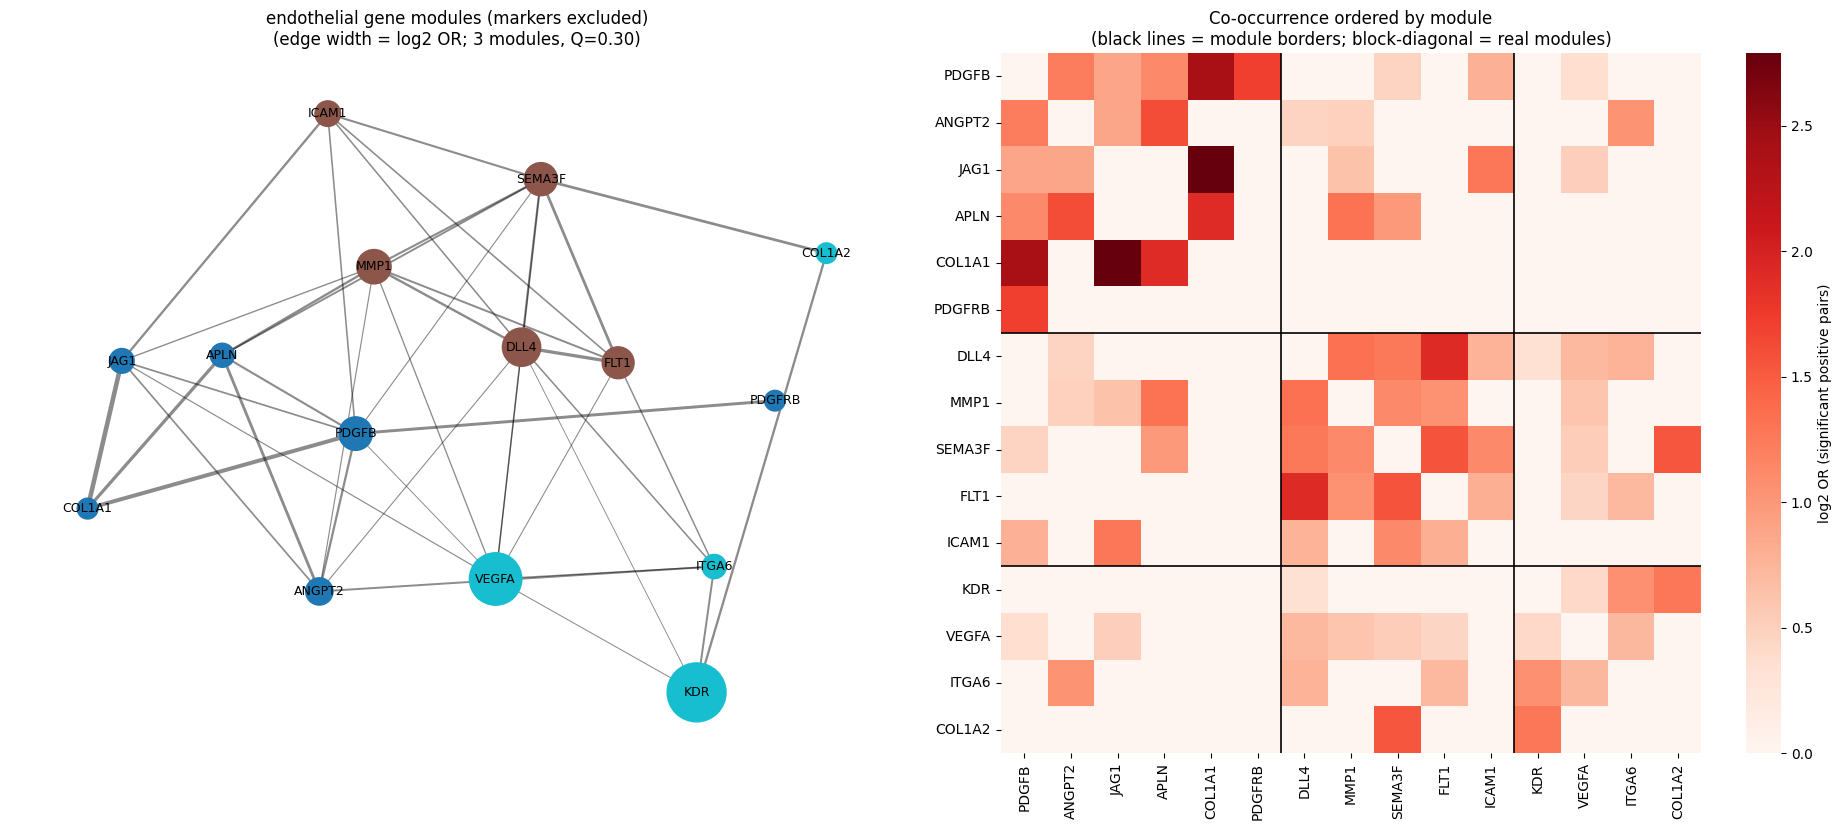

Markers excluded from modules (lineage-defining only): CDH5, PECAM1, VWF
Co-firing gene modules (genes ordered by abundance):
  module 0: PDGFB, ANGPT2, JAG1, APLN, COL1A1, PDGFRB
  module 1: DLL4, MMP1, SEMA3F, FLT1, ICAM1
  module 2: KDR, VEGFA, ITGA6, COL1A2


In [78]:
# ==========================================================================
# GENE-INTERACTION MODULES. Nodes = genes; an edge joins two genes switched ON TOGETHER
# more than chance (positive co-occurrence, Fisher's exact FDR<0.05, each gene ON in
# >= MIN_ON cells) in the ENDOTHELIAL population. Edge WEIGHT / width = log2 odds ratio
# (EFFECT SIZE, not significance - so widths actually vary). Community detection groups
# co-firing genes into MODULES; we report the modularity Q and a resolution sweep so the
# module structure is QUANTIFIED, and an ordered co-occurrence heatmap so it can be
# eyeballed (real modules = a block-diagonal pattern, not a hairball).
# ==========================================================================
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import networkx as nx

MODULE_LINEAGE = "endothelial"     # dominant population
MIN_ON = 20                        # each gene ON in >= this many cells (stable odds ratio)
# Pan-endothelial markers define the lineage but are ON almost everywhere, so they add no
# module structure - drop them and build modules from the functional/programme genes only.
MODULE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1"}
MODULE_GENES = [g for g in GENES if g not in MODULE_MARKER_EXCLUDE]

B = df[(df["cell_type"] == MODULE_LINEAGE) & df["had_reads"]][MODULE_GENES].to_numpy()
on_count = B.sum(0)
on_freq = B.mean(0)

rows = []
for i in range(len(MODULE_GENES)):
    for j in range(i + 1, len(MODULE_GENES)):
        a = int(((B[:, i] == 1) & (B[:, j] == 1)).sum())      # both on
        b = int(on_count[i]) - a
        c = int(on_count[j]) - a
        d = len(B) - a - b - c
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        _, p = fisher_exact([[a, b], [c, d]])
        rows.append((MODULE_GENES[i], MODULE_GENES[j], np.log2(odds), p, int(on_count[i]), int(on_count[j])))
gp = pd.DataFrame(rows, columns=["g1", "g2", "log2_OR", "pvalue", "n1", "n2"])
gp["FDR"] = multipletests(gp.pvalue, method="fdr_bh")[1]

# Edges = significant positive pairs; weight = log2 OR (effect size).
pos = gp[(gp.log2_OR > 0) & (gp.FDR < 0.05) & (gp.n1 >= MIN_ON) & (gp.n2 >= MIN_ON)].copy()
Ggene = nx.Graph()
Ggene.add_nodes_from(MODULE_GENES)
for r in pos.itertuples():
    Ggene.add_edge(r.g1, r.g2, weight=r.log2_OR)

# Community detection + HOW GOOD the split is (modularity Q; >~0.3 = clear modules).
communities = list(nx.community.greedy_modularity_communities(Ggene, weight="weight"))
module_of = {g: m for m, com in enumerate(communities) for g in com}
n_mod = len(communities)
Q = nx.community.modularity(Ggene, communities, weight="weight")

# Robustness: sweep the Louvain resolution (higher -> more, smaller modules).
print("Resolution sweep (Louvain) - is the module count stable?")
for gamma in [0.5, 0.75, 1.0, 1.5, 2.0]:
    com_g = nx.community.louvain_communities(Ggene, weight="weight", resolution=gamma, seed=0)
    print(f"  resolution={gamma:>4}: {len(com_g)} modules, "
          f"Q={nx.community.modularity(Ggene, com_g, weight='weight'):.3f}")
print(f"\nChosen (greedy) partition: {n_mod} modules, modularity Q = {Q:.3f}  "
      f"(Q ~0 = one interconnected hairball; Q >~0.3 = genuinely modular)\n")

# --- Figure 1: the graph, edge WIDTH = log2 OR (effect size) ---
module_cmap = plt.get_cmap("tab10", max(n_mod, 1))
connected = [g for g in Ggene.nodes() if Ggene.degree(g) > 0]
H = Ggene.subgraph(connected)
layout = nx.spring_layout(H, weight="weight", k=1.4, seed=1)
node_size = [200 + 1600 * on_freq[MODULE_GENES.index(g)] / on_freq.max() for g in H.nodes()]
node_color = [module_cmap(module_of[g]) for g in H.nodes()]
ew = np.array([H[u][v]["weight"] for u, v in H.edges()])
edge_width = 0.3 + 3.0 * ew / ew.max()

fig, axg = plt.subplots(1, 2, figsize=(19, 8))
nx.draw_networkx_edges(H, layout, ax=axg[0], width=edge_width, alpha=0.45)
nx.draw_networkx_nodes(H, layout, ax=axg[0], node_size=node_size, node_color=node_color)
nx.draw_networkx_labels(H, layout, ax=axg[0], font_size=9)
axg[0].set_title(f"{MODULE_LINEAGE} gene modules (markers excluded)\n(edge width = log2 OR; {n_mod} modules, Q={Q:.2f})")
axg[0].axis("off")

# --- Figure 2: co-occurrence matrix ORDERED BY MODULE. Real modules = block-diagonal. ---
order = [g for com in communities for g in sorted(com, key=lambda x: -on_freq[MODULE_GENES.index(x)])]
M = pd.DataFrame(0.0, index=order, columns=order)
for r in pos.itertuples():
    M.loc[r.g1, r.g2] = r.log2_OR
    M.loc[r.g2, r.g1] = r.log2_OR
sns.heatmap(M, cmap="Reds", square=True, ax=axg[1],
            cbar_kws={"label": "log2 OR (significant positive pairs)"})
for bnd in np.cumsum([len(c) for c in communities])[:-1]:
    axg[1].axhline(bnd, color="k", lw=1.2); axg[1].axvline(bnd, color="k", lw=1.2)
axg[1].set_title("Co-occurrence ordered by module\n(black lines = module borders; block-diagonal = real modules)")
plt.tight_layout(); plt.show()

print(f"Markers excluded from modules (lineage-defining only): {', '.join(sorted(MODULE_MARKER_EXCLUDE))}")
print("Co-firing gene modules (genes ordered by abundance):")
for m, com in enumerate(communities):
    ordered = sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)])
    print(f"  module {m}: {', '.join(ordered)}")
isolated = [g for g in MODULE_GENES if Ggene.degree(g) == 0]
if isolated:
    print(f"  no significant positive partner: {', '.join(isolated)}")

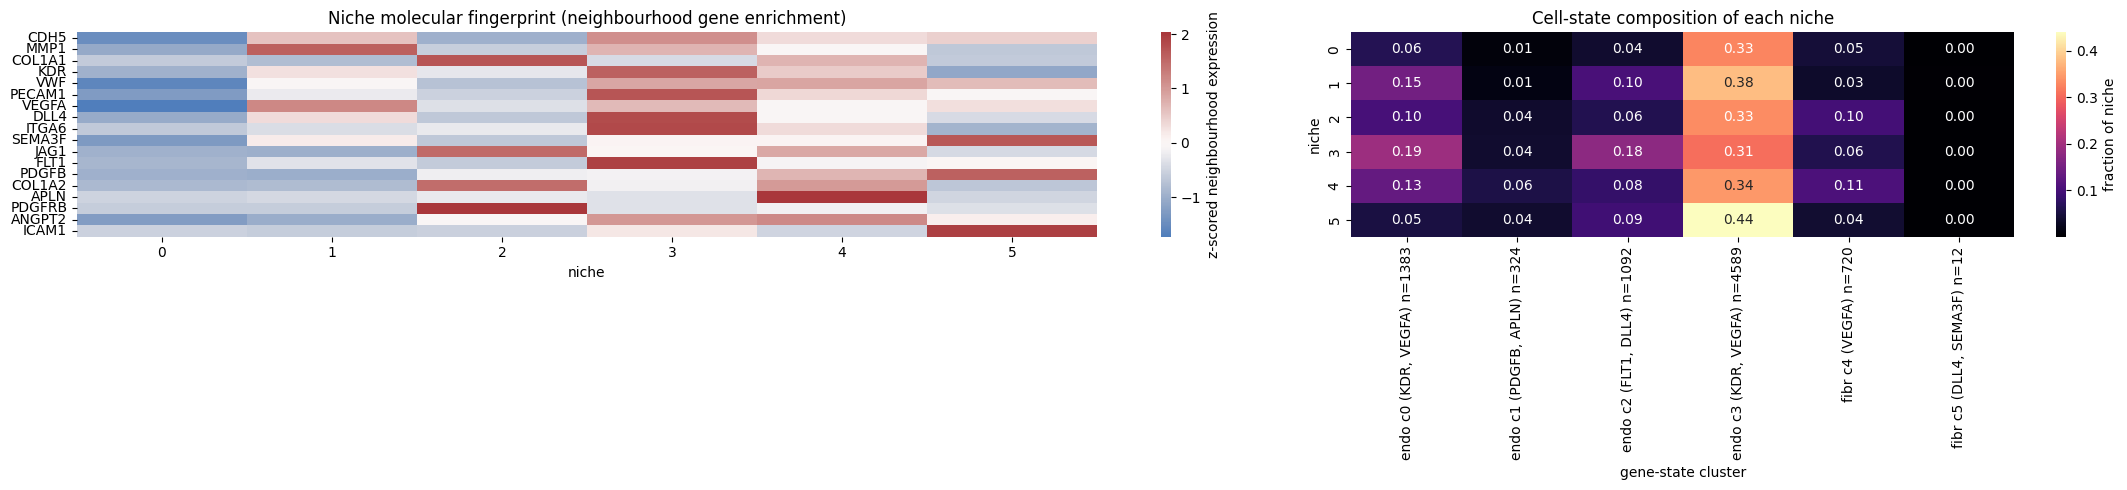

Niche fingerprints (top enriched neighbourhood genes):
  niche 0 (n=4,589): APLN, ICAM1, PDGFRB, COL1A1
  niche 1 (n=2,476): MMP1, VEGFA, CDH5, DLL4
  niche 2 (n=1,311): PDGFRB, COL1A1, JAG1, COL1A2
  niche 3 (n=1,839): FLT1, ITGA6, DLL4, PECAM1
  niche 4 (n=1,061): APLN, ANGPT2, COL1A2, VWF
  niche 5 (n=1,771): ICAM1, SEMA3F, PDGFB, VWF


In [72]:
# WHAT DEFINES EACH NICHE?
#  (left)  z-scored mean neighbourhood gene expression -> the molecular signature of each
#          niche (which genes are enriched among a cell's neighbours in that niche).
#  (right) gene-state cluster composition -> which cell states build each niche.
nb_gene_cols = [f"nb_{g}" for g in GENES]
niche_gene = df.groupby("niche")[nb_gene_cols].mean()
niche_gene_z = (niche_gene - niche_gene.mean()) / (niche_gene.std() + 1e-9)
niche_gene_z.columns = GENES

state_comp = pd.crosstab(df["niche"], df["bmm"], normalize="index").drop(columns=[-1], errors="ignore")
state_comp.columns = [cluster_name_of.get(c, str(c)) for c in state_comp.columns]

fig, axes = plt.subplots(1, 2, figsize=(22, 5), gridspec_kw={"width_ratios": [2, 1.3]})
sns.heatmap(niche_gene_z.T, cmap="vlag", center=0, ax=axes[0],
            cbar_kws={"label": "z-scored neighbourhood expression"})
axes[0].set_title("Niche molecular fingerprint (neighbourhood gene enrichment)")
axes[0].set_xlabel("niche")
sns.heatmap(state_comp, cmap="magma", annot=True, fmt=".2f", ax=axes[1],
            cbar_kws={"label": "fraction of niche"})
axes[1].set_title("Cell-state composition of each niche")
axes[1].set_xlabel("gene-state cluster"); axes[1].set_ylabel("niche")
plt.tight_layout(); plt.show()

print("Niche fingerprints (top enriched neighbourhood genes):")
for niche_id in niche_gene_z.index:
    top = niche_gene_z.loc[niche_id].sort_values(ascending=False).head(4).index.tolist()
    print(f"  niche {niche_id} (n={int((df['niche'] == niche_id).sum()):,}): {', '.join(top)}")

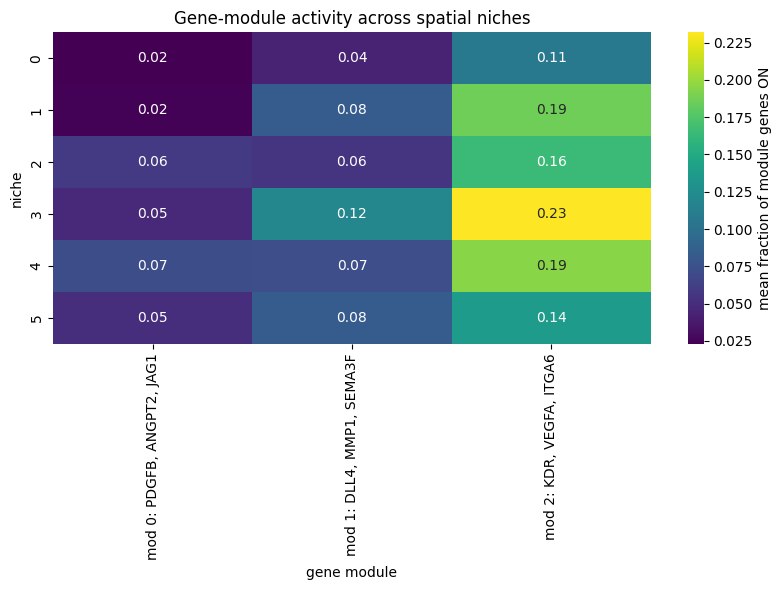

In [79]:
# GENE-MODULE ACTIVITY PER NICHE. For every cell, the fraction of each module's genes
# that are ON; averaged per niche -> which co-firing gene programmes are active where.
module_labels = {m: f"mod {m}: {', '.join(sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)])[:3])}"
                 for m, com in enumerate(communities)}
module_activity = pd.DataFrame(
    {module_labels[m]: df[list(com)].mean(axis=1) for m, com in enumerate(communities)})
module_activity["niche"] = df["niche"].to_numpy()
niche_module = module_activity.groupby("niche").mean()

plt.figure(figsize=(1.4 * len(communities) + 4, 0.5 * df["niche"].nunique() + 3))
sns.heatmap(niche_module, cmap="viridis", annot=True, fmt=".2f",
            cbar_kws={"label": "mean fraction of module genes ON"})
plt.title("Gene-module activity across spatial niches")
plt.xlabel("gene module"); plt.ylabel("niche")
plt.tight_layout(); plt.show()

In [84]:
# ==========================================================================
# IS STATE c1 (APLN/PDGFB sprout) SPATIALLY CLOSE TO PERICYTES?
# Pericyte/mural marker in this panel = PDGFRB. c1 expresses PDGFB, the ligand tip cells
# use to RECRUIT pericytes, so it should sit nearer PDGFRB+ cells than other endothelial
# states. Three independent tests, all restricted to within-image neighbours.
# ==========================================================================
from scipy.stats import mannwhitneyu

endo = df[(df.cell_type == "endothelial") & df.had_reads & (df.bmm >= 0)].copy()
endo_ids = sorted(endo.bmm.unique())
name = {b: cluster_name_of.get(b, str(b)) for b in endo_ids}
c1 = max(endo_ids, key=lambda b: df.loc[df.bmm == b, "APLN"].mean())   # the APLN/PDGFB state
print(f"c1 (APLN/PDGFB sprout) = {name[c1]}\n")

# (1) Fraction of each cell's 15 nearest neighbours that are PDGFRB+ (mural), per endo state.
tab = endo.groupby("bmm")["nb_PDGFRB"].mean().rename(index=name).sort_values(ascending=False)
print("Mean neighbourhood PDGFRB (fraction of 15 neighbours that are PDGFRB+):")
print(tab.round(3), "\n")
p1 = mannwhitneyu(endo.loc[endo.bmm == c1, "nb_PDGFRB"],
                  endo.loc[endo.bmm != c1, "nb_PDGFRB"], alternative="greater").pvalue
print(f"  c1 neighbourhood more PDGFRB+ than other endothelial states? p = {p1:.2e}\n")

# (2) Distance from each endothelial cell to the NEAREST PDGFRB+ cell (same image).
dist = np.full(len(df), np.nan)
for _, sub in df.groupby(IMAGE_KEY):
    peri = sub[sub["PDGFRB"] == 1]
    src = sub[sub["PDGFRB"] == 0]
    if len(peri) and len(src):
        dd, _ = cKDTree(peri[["x_um", "y_um", "z_um"]].to_numpy()).query(
            src[["x_um", "y_um", "z_um"]].to_numpy(), k=1)
        dist[src.index.to_numpy()] = dd
df["dist_to_PDGFRB_um"] = dist
ed = df[(df.cell_type == "endothelial") & df.had_reads & (df.bmm >= 0) & (df["PDGFRB"] == 0)]
print("Median distance (um) from endothelial cell to nearest PDGFRB+ cell, per state:")
print(ed.groupby("bmm")["dist_to_PDGFRB_um"].median().rename(index=name).sort_values(), "\n")
p2 = mannwhitneyu(ed.loc[ed.bmm == c1, "dist_to_PDGFRB_um"].dropna(),
                  ed.loc[ed.bmm != c1, "dist_to_PDGFRB_um"].dropna(), alternative="less").pvalue
print(f"  c1 closer to PDGFRB+ cells than other endothelial states? p = {p2:.2e}\n")

# (3) Permutation-test neighbour-enrichment z between c1 and the mural/fibroblast (PDGFRB+) clusters.
fibro_cols = [c for c in z_all.columns if c.startswith("fibr")]
print("Neighbour-enrichment z (from z_all) between c1 and the PDGFRB+ mural/fibroblast clusters:")
print(z_all.loc[name[c1], fibro_cols].round(2))

c1 (APLN/PDGFB sprout) = endo c1 (PDGFB, APLN) n=324

Mean neighbourhood PDGFRB (fraction of 15 neighbours that are PDGFRB+):
bmm
endo c1 (PDGFB, APLN) n=324    0.027
endo c2 (FLT1, DLL4) n=1092    0.017
endo c0 (KDR, VEGFA) n=1383    0.017
endo c3 (KDR, VEGFA) n=4589    0.016
Name: nb_PDGFRB, dtype: float64 

  c1 neighbourhood more PDGFRB+ than other endothelial states? p = 2.11e-08

Median distance (um) from endothelial cell to nearest PDGFRB+ cell, per state:
bmm
endo c1 (PDGFB, APLN) n=324     79.085700
endo c2 (FLT1, DLL4) n=1092    112.387409
endo c3 (KDR, VEGFA) n=4589    115.938256
endo c0 (KDR, VEGFA) n=1383    118.230765
Name: dist_to_PDGFRB_um, dtype: float64 

  c1 closer to PDGFRB+ cells than other endothelial states? p = 1.35e-16

Neighbour-enrichment z (from z_all) between c1 and the PDGFRB+ mural/fibroblast clusters:
fibr c4 (VEGFA) n=720          0.62
fibr c5 (DLL4, SEMA3F) n=12   -0.91
Name: endo c1 (PDGFB, APLN) n=324, dtype: float64


Image -> timepoint mapping:
  6h     <- dev4_1_6h
  6h     <- dev4_2_6h
  6h     <- dev4_3_6h
  day1   <- dev7_2_day1
  day1   <- dev7_3_day1
  day1   <- dev7_3_day1_large
  day2   <- dev10_1_day2
  day2   <- dev10_3_day2
  day2   <- dev10_4_day2
  day4   <- dev10_2_day4
  day4   <- dev10_4_day4
  day4   <- dev9_4_day4

Cells per timepoint:
timepoint
6h      3513
day1    4285
day2    2611
day4    2638
Name: count, dtype: int64 

Gene-state cluster proportion by timepoint:
 cluster    endo c0 (KDR, VEGFA) n=1383  endo c1 (PDGFB, APLN) n=324  \
timepoint                                                             
6h                               0.059                        0.041   
day1                             0.200                        0.026   
day2                             0.245                        0.054   
day4                             0.173                        0.045   

cluster    endo c2 (FLT1, DLL4) n=1092  endo c3 (KDR, VEGFA) n=4589  \
timepoint               

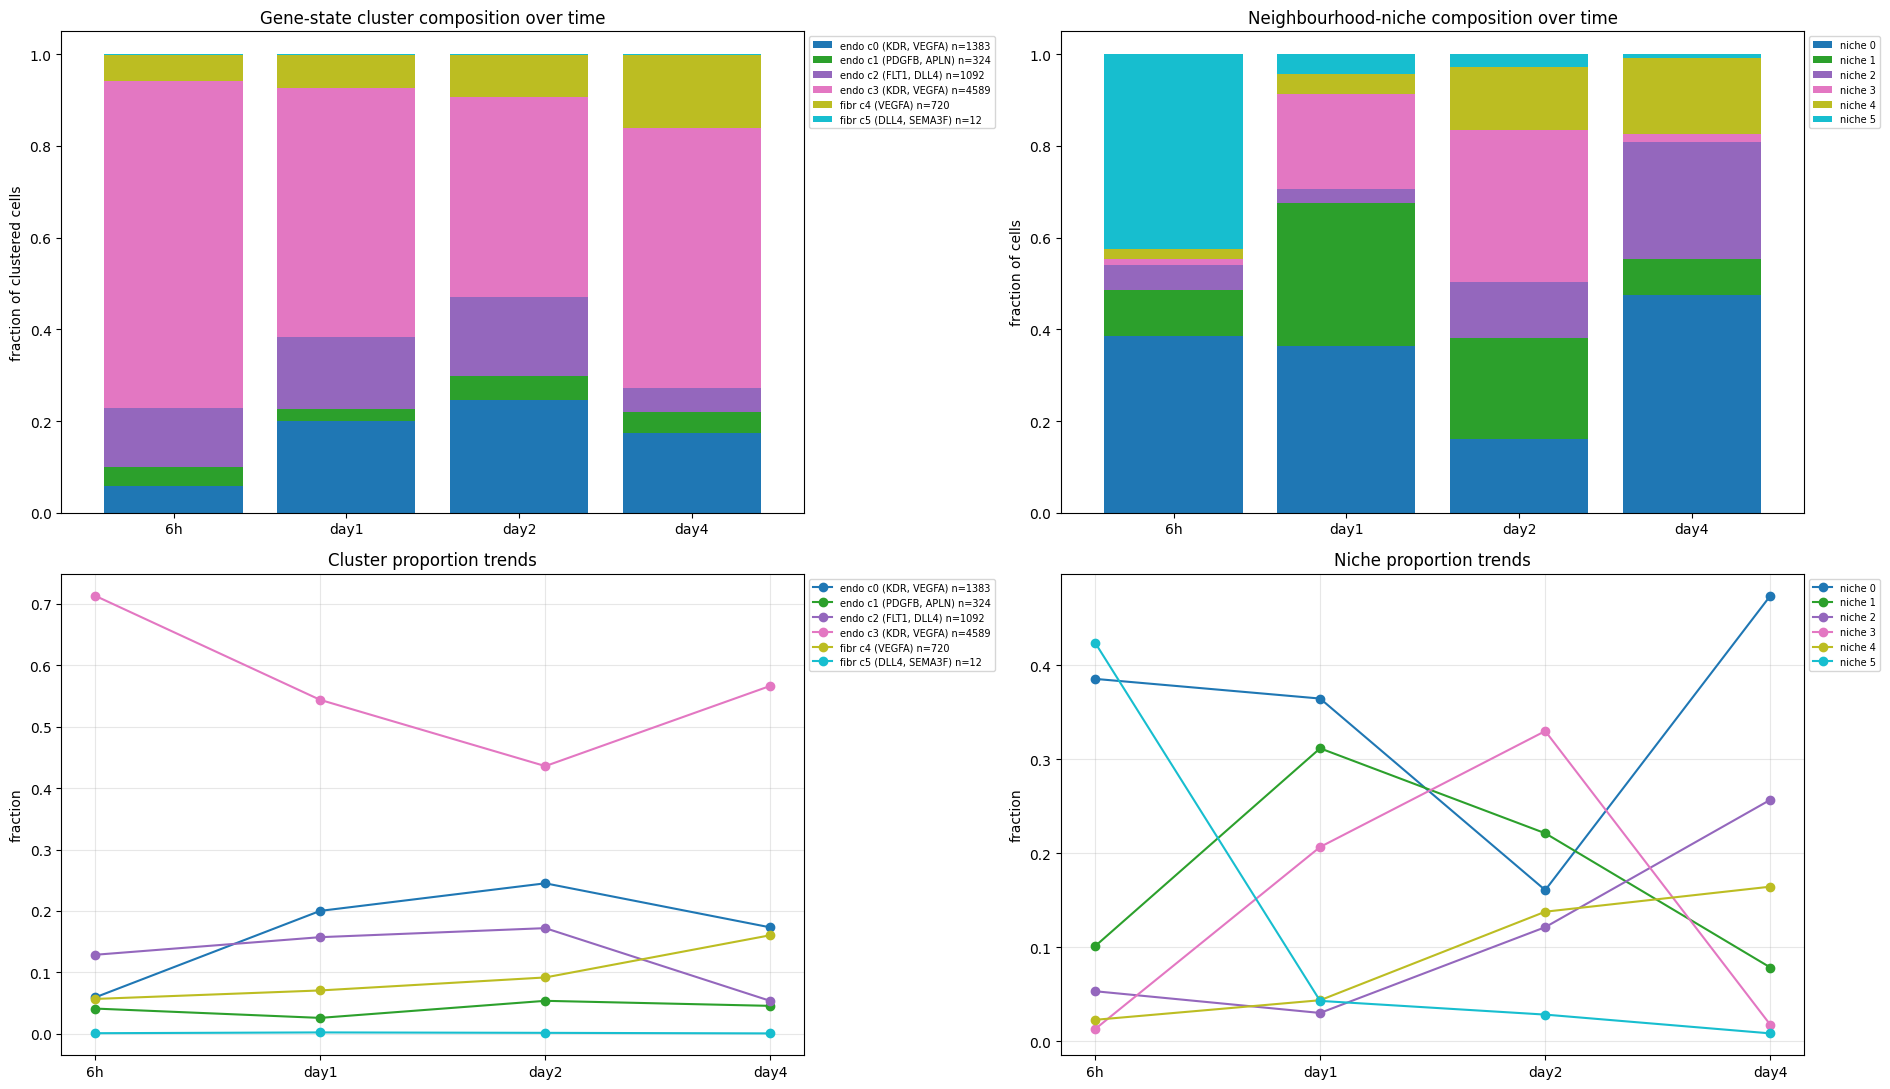

In [86]:
# ==========================================================================
# HOW DO GENE-STATE CLUSTER / NICHE PROPORTIONS CHANGE OVER TIME?
# Timepoint is encoded in the image name (source_folder): 6h -> day1 -> day2 -> day4.
# CAVEAT: each timepoint is a different sample/device (biological-replicate confound), so
# read these as descriptive trends, not statistically powered change.
# ==========================================================================
import re

TIME_ORDER = ["6h", "day1", "day2", "day4"]

def _timepoint(name):
    s = str(name).lower().replace(" ", "")
    if "6h" in s:                                  return "6h"
    if "day4" in s or re.search(r"d4(?!\d)", s):   return "day4"
    if "day2" in s or re.search(r"d2(?!\d)", s):   return "day2"
    if "day1" in s or re.search(r"d1(?!\d)", s):   return "day1"
    return "unknown"

df["timepoint"] = pd.Categorical(df[IMAGE_KEY].map(_timepoint),
                                 categories=TIME_ORDER + ["unknown"], ordered=True)

print("Image -> timepoint mapping:")
for img, tp in sorted(df.groupby(IMAGE_KEY)["timepoint"].first().items(), key=lambda kv: str(kv[1])):
    print(f"  {str(tp):6} <- {img}")
print("\nCells per timepoint:")
print(df["timepoint"].value_counts().reindex(TIME_ORDER), "\n")

tp_valid = [t for t in TIME_ORDER if (df["timepoint"] == t).any()]

# Proportions per timepoint (each column sums to 1 within a timepoint).
clus = df[df["bmm"] >= 0].copy()
clus["cluster"] = clus["bmm"].map(cluster_name_of)
clus_prop = pd.crosstab(clus["timepoint"], clus["cluster"], normalize="index").reindex(tp_valid)
clus_prop = clus_prop[[c for c in cluster_names if c in clus_prop.columns]]
niche_prop = pd.crosstab(df["timepoint"], df["niche"], normalize="index").reindex(tp_valid)

print("Gene-state cluster proportion by timepoint:\n", clus_prop.round(3), "\n")
print("Niche proportion by timepoint:\n", niche_prop.round(3))

fig, ax = plt.subplots(2, 2, figsize=(19, 11))
# Row 0: stacked-bar composition. Row 1: per-group line trends.
clus_colors = [cluster_palette[c] for c in clus_prop.columns]
niche_colors = [niche_color[n] for n in niche_prop.columns]

clus_prop.plot(kind="bar", stacked=True, ax=ax[0, 0], color=clus_colors, width=0.8)
ax[0, 0].set(title="Gene-state cluster composition over time", ylabel="fraction of clustered cells", xlabel="")
ax[0, 0].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax[0, 0].tick_params(axis="x", rotation=0)

niche_prop.plot(kind="bar", stacked=True, ax=ax[0, 1], color=niche_colors, width=0.8)
ax[0, 1].set(title="Neighbourhood-niche composition over time", ylabel="fraction of cells", xlabel="")
ax[0, 1].legend([f"niche {n}" for n in niche_prop.columns], fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax[0, 1].tick_params(axis="x", rotation=0)

for c, col in zip(clus_prop.columns, clus_colors):
    ax[1, 0].plot(range(len(tp_valid)), clus_prop[c].values, "o-", color=col, label=c)
ax[1, 0].set(title="Cluster proportion trends", ylabel="fraction", xticks=range(len(tp_valid)))
ax[1, 0].set_xticklabels(tp_valid); ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")

for n, col in zip(niche_prop.columns, niche_colors):
    ax[1, 1].plot(range(len(tp_valid)), niche_prop[n].values, "o-", color=col, label=f"niche {n}")
ax[1, 1].set(title="Niche proportion trends", ylabel="fraction", xticks=range(len(tp_valid)))
ax[1, 1].set_xticklabels(tp_valid); ax[1, 1].grid(alpha=0.3)
ax[1, 1].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")

plt.tight_layout(); plt.show()

### Conclusions - gene modules

**Approach.** A gene-gene graph from significant **positive** co-occurrences in endothelial
cells. Edge weight = **log2 odds ratio (effect size)**, so edge width reflects *how much* two
genes co-fire, not just significance. The three **pan-endothelial marker genes** (`CDH5`,
`VWF`, `PECAM1`) are **excluded** here - they define the lineage but are ON almost everywhere,
so they carry no module information. Communities on the remaining functional genes = co-firing
**modules**; module activity is then averaged per niche.

**How real are the modules? (quantified, not eyeballed).** With the markers removed the
structure *sharpens*: the greedy partition gives **3 modules at modularity Q = 0.30** - right
at the usual Q > ~0.3 "genuinely modular" threshold (dropping the ubiquitous markers raised Q
from ~0.26). The Louvain **resolution sweep is also more stable**: a robust **2-module** split
holds from low resolution up to resolution 1 (Q=0.30), splitting further into 4-6 only at high
resolution. So there is a solid two-block backbone that resolves into three interpretable
modules; the finer boundaries beyond that are still resolution-dependent, so don't over-read
them.

**Assumptions / drawbacks.** Co-occurrence is association, not causal regulation. Only positive
edges are used; the finer partition depends on the resolution parameter (shown above); and this
is built on endothelial cells only (the dominant lineage).

**Biology - three co-firing modules:**
- **Angiogenic core** - `KDR`, `VEGFA`, `ITGA6` (+`COL1A2`): the VEGF-activation programme.
- **Tip / sprouting** - `DLL4`, `MMP1`, `SEMA3F`, `FLT1`, `ICAM1`: Notch tip-selection +
  ECM-remodelling/guidance genes.
- **Mature-vessel / mural-remodelling** - `PDGFB`, `ANGPT2`, `JAG1`, `APLN`, `COL1A1`,
  `PDGFRB`: vessel destabilisation, pericyte recruitment and collagen/mural genes.

**Do the methods agree?** Yes. These three modules map directly onto the Bernoulli endothelial
states (`KDR`/`VEGFA` core = c0; `DLL4`/`FLT1`/`MMP1` tip = c2) and the angiogenic vs mural
niches. All three views (gene states, gene modules, spatial niches) converge on the **same 2-3
endothelial programmes**, and with the markers dropped the module view is now a genuinely
modular (Q~0.30) corroboration rather than the softest of the three.

---

## Overall biological conclusion

The sample is a **majority-endothelial vascular bed** (~7.4k endothelial vs ~0.7k
fibroblast cells with reads) with a minor, discrete fibroblast population. Endothelial cells
are **not discrete cell types but a continuum** on a shared `CDH5` (VE-cadherin) backbone,
structured by a small number of overlapping programmes.

### Marker glossary (what the genes mean here)

| Gene | Role | Programme it marks |
|---|---|---|
| `CDH5` (VE-cadherin) | pan-endothelial junctional identity | backbone (all endothelium) |
| `KDR` (VEGFR2) | main pro-angiogenic VEGF receptor | **angiogenic core** |
| `VEGFA` | pro-angiogenic ligand (auto/paracrine) | **angiogenic core** |
| `ITGA6` | laminin integrin, migration / basement membrane | angiogenic core |
| `DLL4` | Notch ligand, **tip-cell selection** | **tip / sprouting** |
| `FLT1` (VEGFR1) | VEGF decoy receptor, tip/stalk balance | **tip / sprouting** |
| `MMP1` | matrix metalloprotease, ECM breakdown for sprouting | **tip / sprouting** |
| `SEMA3F` | semaphorin guidance cue | tip / sprouting |
| `ICAM1` | endothelial activation / adhesion | tip / sprouting (activated) |
| `APLN` (apelin) | classic **tip-cell** marker | sprouting front |
| `PDGFB` | pericyte-recruitment signal from tip cells | sprouting -> mural |
| `ANGPT2` | Tie2 ligand, vessel destabilisation / remodelling | mature-vessel / remodelling |
| `VWF`, `PECAM1` | mature/large-vessel endothelial markers | mature vessel |
| `JAG1` | Notch ligand (stalk / mural) | mature-vessel / mural |
| `PDGFRB`, `COL1A1/2` | mural / fibroblast markers | non-angiogenic stroma |

### The endothelial gene-state clusters (Section 2, markers `CDH5`/`VWF`/`PECAM1` excluded from the clustering)

| State | n (%) | Defining markers (upregulated) | Spatial cohesion z | What it is | Angiogenic? |
|---|---|---|---|---|---|
| **c3 - quiescent backbone** | 4,589 (62%) | `CDH5` only, low `KDR` | +4.5 (mostly diffuse) | resting / phalanx endothelium | **no** |
| **c0 - VEGF-activated** | 1,383 (19%) | `KDR` + `VEGFA` | +6.6 | canonical angiogenic activation | **YES (core)** |
| **c2 - tip / sprouting** | 1,092 (15%) | `FLT1` + `DLL4` (+`VEGFA`) | **+9.3 (strongest patches)** | sprouting tip / stalk front | **YES (tip)** |
| **c1 - apelin / PDGFB sprout** | 324 (4%) | `APLN` + `PDGFB` (+`VEGFA`/`DLL4`) | +5.9 | apelin+ tip-like, pericyte-recruiting | **YES (tip-associated)** |

So the **angiogenic states are c0, c2 and c1**:
- **c0** is the *core VEGF-driven angiogenic* state - `KDR`(VEGFR2) receiving `VEGFA` on the
  `CDH5` backbone. This is the main axis of the whole endothelial continuum (it is also
  logistic-PCA axis 1: `KDR`+`VEGFA` vs the plain `CDH5` core).
- **c2** is the *tip / sprouting* state - `DLL4`+`FLT1`(+`MMP1`), i.e. Notch-driven tip
  selection plus ECM-remodelling for sprout invasion. It forms the **tightest spatial
  patches (z = +9.3)**, consistent with sprouting fronts being physically clustered.
- **c1** is a smaller *apelin/PDGFB* sprouting-associated state (`APLN` is a textbook
  tip-cell marker; `PDGFB` recruits pericytes) - a tip-to-mural transition flavour.
- **c3** (the 62% majority) is **not** angiogenic - it is `CDH5`-only quiescent endothelium,
  and it is spatially **diffuse** (z only +4.5), i.e. a shared baseline rather than a
  discrete patchy state.

### The same angiogenic signal in the other two views

- **Gene modules (Section 4).** With the pan-endothelial markers (`CDH5`, `VWF`, `PECAM1`)
  dropped, the co-occurrence graph resolves into **three genuinely modular blocks**
  (modularity Q~0.30): an **angiogenic core** (`KDR`, `VEGFA`, `ITGA6`, `COL1A2`), a
  **tip/sprouting** module (`DLL4`, `MMP1`, `SEMA3F`, `FLT1`, `ICAM1` - the genes defining
  states c0 and c2), and a **mature/mural-remodelling** module (`PDGFB`, `ANGPT2`, `JAG1`,
  `APLN`, `COL1A1`, `PDGFRB`). A robust 2-block split underlies these up to resolution 1, so
  this view now *corroborates* the state/niche programmes as an independent modular partition.
- **Spatial niches (Section 3).** The angiogenic niches are **niche 1** (`MMP1`/`VEGFA`/
  `DLL4` - a proteolytic-angiogenic front), **niche 3** (`FLT1`/`ITGA6`/`DLL4` - the
  tip/sprouting niche), and **niche 5** (`ICAM1`/`SEMA3F`/`PDGFB` - activated/guidance),
  with **niche 4** (`APLN`/`ANGPT2`) a remodelling flavour. Niche 2 (`PDGFRB`/`COL1A1`/
  `JAG1`) is mural/fibroblast and niche 0 is low-signal quiescent - the non-angiogenic
  environments.

**Bottom line.** The `KDR`/`VEGFA` **angiogenic activation** axis (state c0) and the
`DLL4`/`FLT1`/`MMP1` **tip/sprouting** axis (state c2) are the two angiogenic programmes, and
they recur as gene-state clusters, gene modules, and spatial niches - and form real spatial
patches. The bulk `CDH5`-only endothelium is quiescent and diffuse, and fibroblasts
(`PDGFRB`/collagen) are few, discrete, and spatially segregated from the angiogenic
endothelium.

**Caveats to keep in mind:** the gene-module partition is only **modestly modular** (Q~0.30,
and finer splits are resolution-dependent) - the three-module structure is clear but the exact
boundaries beyond the two-block backbone should not be over-read; all-0-read cells were
assigned lineages artificially and carry no state; co-occurrence and spatial adjacency are
associations, not proof of interaction or regulation; very small clusters (e.g. c1 n=324, or
the n~12 fibroblast state) and the chosen k / niche-count are not robust; marker identities
above are the conventional vascular-biology readings of these genes, not validated here; and
this is a single replicate.

# Step-by-step results write-up

A narrative walk-through of the key results with the figures embedded. **Run the code cell
directly below first** - it regenerates the key figures from the analysis above and saves
them to `report_figures/`, which the write-up then embeds.

In [80]:
# ==========================================================================
# SAVE KEY REPORT FIGURES for the write-up below - regenerated compactly from variables
# already in memory and written to report_figures/ (embedded by the markdown that follows).
# ==========================================================================
from matplotlib.colors import BoundaryNorm

fig_dir = output_dir / "report_figures"
fig_dir.mkdir(exist_ok=True)

# 1) Endothelial continuum diagnostics: confidence hist + logistic-PCA curve + latent scatter.
r = res_endo_all
K = r["K"]; mr = r["max_resp"]; de = r["dev_explained"]; sc = r["lpca_scores"]; lab = r["bmm_labels"]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].hist(mr, bins=30, range=(1 / K, 1), color="steelblue"); ax[0].axvline(0.8, color="red", ls="--")
ax[0].set(title=f"Endothelial assignment confidence\n({100 * np.mean(mr >= 0.8):.0f}% cells >=0.8 -> continuum)",
          xlabel="max responsibility per cell", ylabel="cells")
ks = list(de); ax[1].plot(ks, [100 * de[k] for k in ks], "o-"); ax[1].grid(alpha=.3)
ax[1].set(title="Logistic PCA: no early plateau -> many small axes", ylim=(0, 100),
          xlabel="# latent axes", ylabel="% deviance explained")
cmap = plt.get_cmap("tab10", K); norm = BoundaryNorm(np.arange(-.5, K + .5, 1), K)
s = ax[2].scatter(sc[:, 0], sc[:, 1], c=lab, cmap=cmap, norm=norm, s=8, alpha=.6)
ax[2].set(title="Cells on latent axes (colour = Bernoulli state)", xlabel="axis 1", ylabel="axis 2")
plt.colorbar(s, ax=ax[2], ticks=range(K), label="state")
plt.tight_layout(); plt.savefig(fig_dir / "fig1_continuum.png", dpi=110, bbox_inches="tight"); plt.close()

# 2) Gene-state cluster spatial co-location (z_all from the all-cells permutation test).
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(z_all, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True, ax=ax,
            cbar_kws={"label": "neighbour-enrichment z"})
ax.set_title("Do gene-state clusters co-locate? (within-image permutation z)")
plt.tight_layout(); plt.savefig(fig_dir / "fig2_spatial.png", dpi=110, bbox_inches="tight"); plt.close()

# 3) Niche molecular fingerprint + cell-state composition.
fig, ax = plt.subplots(1, 2, figsize=(20, 5), gridspec_kw={"width_ratios": [2, 1.3]})
sns.heatmap(niche_gene_z.T, cmap="vlag", center=0, ax=ax[0], cbar_kws={"label": "z neighbourhood expr"})
ax[0].set_title("Niche molecular fingerprint"); ax[0].set_xlabel("niche")
sns.heatmap(state_comp, cmap="magma", annot=True, fmt=".2f", ax=ax[1], cbar_kws={"label": "fraction"})
ax[1].set_title("Cell-state composition of each niche"); ax[1].set_xlabel("state"); ax[1].set_ylabel("niche")
plt.tight_layout(); plt.savefig(fig_dir / "fig3_niches.png", dpi=110, bbox_inches="tight"); plt.close()

# 4) Gene-interaction module graph.
_conn = [g for g in Ggene.nodes() if Ggene.degree(g) > 0]
Hs = Ggene.subgraph(_conn)
lay = nx.spring_layout(Hs, weight="weight", k=1.4, seed=1)
mcmap = plt.get_cmap("tab10", max(len(communities), 1))
nsz = [200 + 1600 * on_freq[MODULE_GENES.index(g)] / on_freq.max() for g in Hs.nodes()]
ncol = [mcmap(module_of[g]) for g in Hs.nodes()]
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(Hs, lay, ax=ax, alpha=.35)
nx.draw_networkx_nodes(Hs, lay, ax=ax, node_size=nsz, node_color=ncol)
nx.draw_networkx_labels(Hs, lay, ax=ax, font_size=9)
ax.set_title("Endothelial gene-interaction modules (positive co-occurrence)"); ax.axis("off")
plt.tight_layout(); plt.savefig(fig_dir / "fig4_modules.png", dpi=110, bbox_inches="tight"); plt.close()

# 5) Gene-module activity per niche.
fig, ax = plt.subplots(figsize=(1.4 * len(communities) + 4, 0.5 * len(niche_module) + 3))
sns.heatmap(niche_module, cmap="viridis", annot=True, fmt=".2f", ax=ax,
            cbar_kws={"label": "mean fraction of module genes ON"})
ax.set_title("Gene-module activity across niches"); ax.set_xlabel("module"); ax.set_ylabel("niche")
plt.tight_layout(); plt.savefig(fig_dir / "fig5_module_niche.png", dpi=110, bbox_inches="tight"); plt.close()

print("Saved report figures ->", fig_dir)

Saved report figures -> c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish\report_figures


## 1. Are endothelial cells discrete types or a continuum?

Endothelial cells were clustered on their 18-gene on/off profile, with the lineage markers
`CDH5`/`VWF`/`PECAM1` **excluded** so the clusters capture *function*, not identity. We then
probed the result three independent ways.

![Endothelial continuum diagnostics](report_figures/fig1_continuum.png)

- **Left - assignment confidence.** Only ~38% of cells are confidently placed in one state
  (>=0.8); most sit *between* states. A discrete population would pile up against 1.0.
- **Middle - logistic PCA.** The deviance-explained curve keeps climbing with no early
  plateau - no single "dial" captures the cells; they spread along many small axes.
- **Right - cells on the latent axes.** One continuous cloud that the Bernoulli state colours
  merely slice up, rather than separated islands.

**Conclusion:** endothelial cells form a **structured continuum**, whose dominant axis is
`KDR`/`VEGFA` angiogenic activation on the shared `CDH5` backbone. (Run separately,
fibroblasts were 99% confidently sorted into 2 clean states - genuinely **discrete** - so the
continuum is specific to endothelium.)

## 2. Are the gene-state clusters "real" in tissue?

Every cell was labelled with its state, then a within-image label-shuffling permutation test
asked whether cells of the same state sit together more than chance (diagonal) and which
states neighbour which (off-diagonal).

![Gene-state cluster spatial co-location](report_figures/fig2_spatial.png)

- The **angiogenic states are spatially cohesive** - the `KDR`/`VEGFA` state (z ~ +6.6) and
  especially the `FLT1`/`DLL4` tip state (z ~ +9.3, the tightest patches).
- The **`CDH5`-only backbone is spatially diffuse** (z ~ +4.5) - a shared baseline, not a
  discrete patch.
- Collagen fibroblasts sit **apart** from the angiogenic endothelium (negative off-diagonal),
  not intermixed.

**Conclusion:** the *functional* (angiogenic / sprouting) states occupy genuine tissue
territory; the backbone does not.

## 3. What defines the spatial niches?

Niches are recurring neighbourhood micro-environments, built from the neighbourhood
expression of the informative genes only (cell-type composition, entropy and lineage markers
were deliberately excluded, or the niches just track "endothelial-dense vs mixed").

![Niche molecular fingerprint and cell-state composition](report_figures/fig3_niches.png)

Each niche has a distinct molecular signature (left) and cell-state composition (right):
a `MMP1`/`VEGFA` proteolytic-angiogenic niche, a `FLT1`/`DLL4`/`ITGA6` tip/sprouting niche,
an `APLN`/`ANGPT2` remodelling niche, and a `PDGFRB`/`JAG1` mural/fibroblast niche.

## 4. Which genes act together? (gene modules)

A gene-gene graph of significant **positive** co-occurrences (edge weight = `-log10 FDR`) in
endothelial cells; communities are co-firing **modules**.

![Gene-interaction modules](report_figures/fig4_modules.png)

Three modules emerge: an **angiogenic core** (`CDH5`, `KDR`, `VEGFA`, `ITGA6`), a
**tip/sprouting** module (`DLL4`, `MMP1`, `FLT1`, `SEMA3F`, `ICAM1`), and a
**mature-vessel / mural** module (`VWF`, `PECAM1`, `ANGPT2`, `JAG1`, `PDGFB`, `APLN` +
collagen).

## 5. Do the modules map onto tissue? (module x niche)

![Gene-module activity across niches](report_figures/fig5_module_niche.png)

The angiogenic and tip/sprouting modules light up in exactly the angiogenic / tip niches,
tying the abstract gene programmes back to physical tissue location.

## How the methods agree

Three independent methods - clustering the cells, a gene co-occurrence graph, and spatial
neighbourhoods - converge on the **same 2-3 endothelial programmes**:

| Programme | Gene-state cluster (Sec 2) | Gene module (Sec 4) | Spatial niche (Sec 3) |
|---|---|---|---|
| **Angiogenic core** | c0 `KDR`/`VEGFA` | angiogenic-core module | niche 1 (`MMP1`/`VEGFA`) |
| **Tip / sprouting** | c2 `FLT1`/`DLL4` | tip/sprouting module | niche 3 (`FLT1`/`DLL4`) |
| **Mature / mural** | c1 `APLN`/`PDGFB` | mature-vessel module | niche 2 & 4 (`PDGFRB`/`ANGPT2`) |
| **Quiescent backbone** | c3 `CDH5` only | (core module, low) | niche 0 (low signal) |

The two angiogenic programmes (core VEGF activation and tip/sprouting) additionally form
**genuine spatial patches**, while the quiescent `CDH5` backbone is spread diffusely. See the
**Overall biological conclusion** above for the full marker glossary and caveats.